In [36]:
import pandas as pd

In [85]:
!pip install mlflow

Python(76568) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import sys
sys.path.append('..')

In [38]:
import pandas as pd
from utils.data_enedis_ademe import DataEnedisAdeme

/Users/tharse/projet-dpe/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


#### Consommation d'électricité annuelle résidentielle par adresse

*Le jeu de données présente la consommation électrique annuelle des adresses de 10 logements ou plus. Un logement correspond à un point de livraison (ou PDL) de type résidentiel.<br>Les données sont mises à disposition à titre purement indicatif sans garantie quant au degré de fiabilité des adresses. Enedis ne saurait, par conséquent, être tenue responsable en cas de défaut de fiabilité.<br>À partir de 2021 et suite à un changement dans le référentiel des adresses, la normalisation de celles-ci peut faire apparaitre des écarts avec les années précédentes.*

In [39]:
tmp_url = "https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?select=segment_de_client%2C%20annee%2C%20count\
    (code_iris)%20as%20nb%2C%20min(nombre_de_logements)%20as%20nb_min_logements%2C%20max(nombre_de_logements)%20as%20nb_max_logements&group_by=segment_de_client%2C%20annee&limit=20"

DataEnedisAdeme().load_get_data_pandas(tmp_url)

,segment_de_client,annee,nb,nb_min_logements,nb_max_logements
0,RESIDENTIEL,2018-01-01T00:00:00+00:00,391099,10,1189
1,RESIDENTIEL,2019-01-01T00:00:00+00:00,399791,10,1124
2,RESIDENTIEL,2020-01-01T00:00:00+00:00,405605,10,1435
3,RESIDENTIEL,2021-01-01T00:00:00+00:00,407053,10,1189
4,RESIDENTIEL,2022-01-01T00:00:00+00:00,394100,10,1190
5,RESIDENTIEL,2023-01-01T00:00:00+00:00,397398,10,1196


*Avec ceci on voit que les adresses Enedis sont des logements 'residentiels' avec au moins 10 logements et au plus +de 1000 logements. Une fois la correspondance faite avec la base de l'ADEME - DPE depuis 2021 on le dataset suivant :*

*Echantillon pour l'étude : périmètre Paris 2018*

In [40]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2018_400k_rows_250_min_comp.parquet', engine='pyarrow')
df.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,16170.8,0.0,1548.3,Paris,2987.6,0.0,1548.3,0,16170.8,1083.0,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
1,20081.5,0.0,5617.0,Paris,3737.2,0.0,5617.0,0,20081.5,2150.5,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
2,38501.7,0.0,5812.1,Paris,10285.3,0.0,5812.1,0,38501.7,3529.6,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
3,39468.7,0.0,6130.1,Paris,10508.7,0.0,6130.1,0,39468.7,3637.1,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
4,15376.1,0.0,5752.4,Paris,2816.4,0.0,5752.4,0,15376.1,1186.5,...,6863783.96,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.282777,48.871931,None


# Exploration

In [92]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465961 entries, 0 to 465960
Columns: 280 entries, Conso_chauffage_dépensier_é_finale_ademe to _type_enedis_with_ban
dtypes: float64(144), int64(7), object(129)
memory usage: 995.4+ MB


In [94]:
df.isna().any()[df.isna().any()==True].index.to_list()

['Volume_stockage_générateur_ECS_n°1_ademe',
 'Conso_é_finale_installation_ECS_ademe',
 'Conso_ECS_é_finale_énergie_n°2_ademe',
 'Besoin_refroidissement_ademe',
 'Conso_chauffage_dépensier_installation_chauffage_n°1_ademe',
 'Coût_total_5_usages_ademe',
 'Configuration_installation_chauffage_n°1_ademe',
 'Conso_é_finale_dépensier_installation_ECS_ademe',
 'Configuration_installation_ECS_ademe',
 'Type_installation_chauffage_n°1_ademe',
 'Surface_chauffée_installation_chauffage_n°1_ademe',
 'Nombre_niveau_logement_ademe',
 'Apports_internes_saison_froid_ademe',
 'Type_installation_ECS_(général)_ademe',
 'Déperditions_murs_ademe',
 'Conso_5_usages_par_m²_é_primaire_ademe',
 'Usage_générateur_ECS_n°1_ademe',
 'Coût_ECS_dépensier_ademe',
 'Emission_GES_auxiliaires_ademe',
 'Emission_GES_5_usages_par_m²_ademe',
 'Apports_solaires_saison_froid_ademe',
 'N°_étage_appartement_ademe',
 'Type_énergie_générateur_ECS_n°1_ademe',
 'Coût_ECS_ademe',
 'Surface_habitable_desservie_par_installation_ECS

In [95]:
df["Tri des adresses_enedis_with_ban"].dtypes


dtype('int64')

In [96]:
class preprocessing :
    def __init__(self, df):
        self.df = df.copy()
        self.cast_object_columns_step = False #???
        
    def get_entropy(self, pk, L):
        op= - (pk * np.log(pk) / np.log(L)).sum()
        return op

    def delete_colnan (self, tauxseuil):
        print("delete_colnan")
        print("Le dataframe contient initialement {} colonnes et {} lignes.".format(len(self.df.columns), len(self.df)))
        print("Start processing : columns identification ...")
        nanames = []
        entro = []
        extra = ["Code_INSEE_(BAN)_ademe","Code IRIS_enedis_with_ban","Code_postal_(brut)_ademe","Code_postal_(BAN)_ademe","Numéro de voie_enedis_with_ban",
                "Nombre de logements_enedis_with_ban","Tri des adresses_enedis_with_ban","postcode_enedis_with_ban","citycode_enedis_with_ban"]
        for c in self.df.columns:
            tauxnan = round(self.df[c].isna().sum()/len(self.df),2)
            pk = df[c].value_counts(normalize=True, dropna = False).values
            entropy = round(self.get_entropy(pk, len(self.df)),2)
            if tauxnan >= tauxseuil:
                nanames.append(c)
                # print("***", c, "***")
                # print(tauxnan)
            if c[0]=="_" and "geo" not in c:
                extra.append(c)
            if entropy == 1 or entropy == 0:
                entro.append(c)
        print("Il y a {} colonnes vides à, au moins, {}% , {} colonnes avec une entropy de 0 ou 1 et {} colonnes inutiles".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
        print("Start processing : columns deleting ...")
        self.df=self.df.drop(nanames+entro+extra, axis=1).drop_duplicates()
        print("Done deleting columns")
        print("Il reste {} colonnes et {} lignes.".format(len(self.df.columns), len(self.df)))
        print(self.df.info())
        return self

    
    def cast_object_columns(self):
        print("Start processing : columns encoding ...")
        if not self.cast_object_columns_step:
            cols_obj = self.df.select_dtypes(include='O').columns
            for c in cols_obj:
                # self.df[c] = self.df[c].str.replace(',', '.')
                # self.df[c] = self.df[c].fillna(-999999)
                try:
                    self.df[c] = pd.to_numeric(self.df[c].str.replace(',','.'), errors='raise')
                except Exception as e:
                    try:
                        self.df[c] = pd.to_datetime(self.df[c])
                    except Exception as e:
                        self.df[c] = self.df[c].astype('string')
            print("Casting done...")
            self.cast_object_columns_step = True
        print(self.df.info())
        print("done cast_object_columns")
        return self
    

    def fillnan(self):
        # print("fillnan")
        print(self.df.info())
        # col_fill_median = []
        # col_fill_mean = []
        for col in self.df.select_dtypes(include ='float').columns:
            if self.df[col].isna().any():
                # print(self.df[col].dtypes)
                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)
                IQR = Q3 - Q1
                born_inf =(self.df[col]<(Q1-1.5*IQR)).value_counts()
                born_sup = (self.df[col]>(Q3+1.5*IQR)).value_counts()
                try:
                    born_inf[1]
                    #col_fill_median.append(col)
                    self.df[col].fillna(self.df[col].median(), inplace=True )
                    # print("le type",self.df[col].dtypes)
                except Exception as e:
                    try:
                        born_sup[1]
                        #col_fill_median.append(col)
                        self.df[col].fillna(self.df[col].median(), inplace=True)
                        # print("le type",self.df[col].dtypes)
                    except Exception as e:
                        #col_fill_mean.append(col)
                        # self.df[col].fillna(self.df[col].mean, inplace=True)
                        self.df[col] = self.df[col].fillna(self.df[col].mean())
                        # print("le type",self.df[col].dtypes)
        # print("le nomnbre de colonnes traitées:", len(df.select_dtypes(['int','float']).columns))
        # print(len(col_fill_median))
        # print(len(col_fill_mean))
        # print(self.df.info())
        print("done fillnan")
        return self

In [97]:
df_clean = preprocessing(df).delete_colnan(0.9).cast_object_columns().fillnan().df
df_clean_col = df_clean.drop(columns=df_clean.select_dtypes(include='datetime').columns)
df_clean_col.info()

delete_colnan
Le dataframe contient initialement 280 colonnes et 465961 lignes.
Start processing : columns identification ...
Il y a 76 colonnes vides à, au moins, 90.0% , 55 colonnes avec une entropy de 0 ou 1 et 14 colonnes inutiles
Start processing : columns deleting ...
Done deleting columns
Il reste 174 colonnes et 437073 lignes.
<class 'pandas.core.frame.DataFrame'>
Index: 437073 entries, 0 to 465960
Columns: 174 entries, Conso_chauffage_dépensier_é_finale_ademe to lat_enedis_with_ban
dtypes: float64(104), object(70)
memory usage: 583.6+ MB
None
Start processing : columns encoding ...


KeyboardInterrupt: 

In [45]:
# Afficher les premières lignes du DataFrame pour vérifier les données
print(df_clean_col.head())

   Conso_chauffage_dépensier_é_finale_ademe  \
0                                   16170.8   
1                                   20081.5   
2                                   38501.7   
3                                   39468.7   
4                                   15376.1   

   Volume_stockage_générateur_ECS_n°1_ademe  \
0                                       0.0   
1                                       0.0   
2                                       0.0   
3                                       0.0   
4                                       0.0   

   Conso_é_finale_installation_ECS_ademe  Emission_GES_chauffage_ademe  \
0                                 1548.3                        2987.6   
1                                 5617.0                        3737.2   
2                                 5812.1                       10285.3   
3                                 6130.1                       10508.7   
4                                 5752.4                        

In [27]:
# Afficher toutes les colonnes du DataFrame
print(df_clean_col.columns)

Index(['Conso_chauffage_dépensier_é_finale_ademe',
       'Volume_stockage_générateur_ECS_n°1_ademe',
       'Conso_é_finale_installation_ECS_ademe', 'Emission_GES_chauffage_ademe',
       'Conso_ECS_é_finale_énergie_n°2_ademe',
       'Conso_ECS_é_finale_énergie_n°1_ademe', 'Besoin_refroidissement_ademe',
       'Conso_chauffage_dépensier_installation_chauffage_n°1_ademe',
       'Coût_total_5_usages_ademe',
       'Configuration_installation_chauffage_n°1_ademe',
       ...
       'id_BAN_enedis_with_ban', 'name_enedis_with_ban', 'x_enedis_with_ban',
       'y_enedis_with_ban', 'district_enedis_with_ban', 'type_enedis_with_ban',
       'importance_enedis_with_ban', 'street_enedis_with_ban',
       'lon_enedis_with_ban', 'lat_enedis_with_ban'],
      dtype='object', length=170)


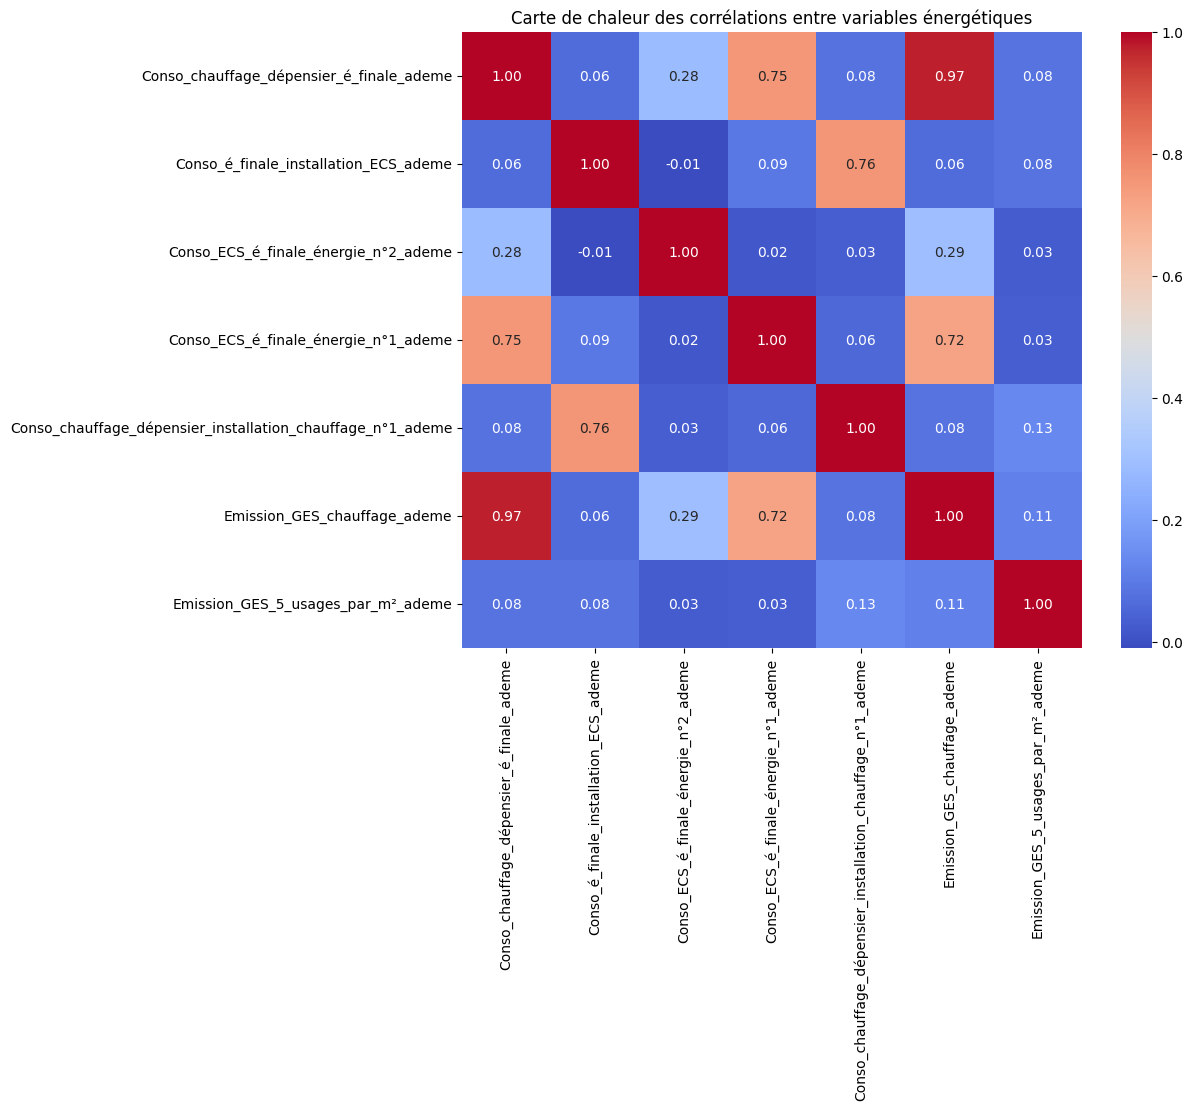

In [ ]:
# Sélectionner les colonnes d'intérêt
cols_correlation = ['Conso_chauffage_dépensier_é_finale_ademe',
                    'Conso_é_finale_installation_ECS_ademe',
                    'Conso_ECS_é_finale_énergie_n°2_ademe',
                    'Conso_ECS_é_finale_énergie_n°1_ademe',
                    'Conso_chauffage_dépensier_installation_chauffage_n°1_ademe',
                    'Emission_GES_chauffage_ademe',
                    'Emission_GES_5_usages_par_m²_ademe']

# Calcul de la matrice de corrélation
corr_matrix = df_clean_col[cols_correlation].corr()

# Affichage de la carte de chaleur
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Carte de chaleur des corrélations entre variables énergétiques")
plt.show()


La forte corrélation entre "Conso_chauffage_dépenisier_é_finale_ademe" et "Emission_GES_chauffage_ademe" suggère que les efforts pour réduire la consommation d'énergie de chauffage auront un impact significatif sur la réduction des émissions de GES liées au chauffage.
La corrélation entre "Conso_chauffage_dépenisier_installation_chauffage_n°1_ademe" et "Conso_é_finale_installation_ECS_ademe" (0.76) pourrait indiquer que les bâtiments avec une forte consommation de chauffage ont également tendance à avoir une forte consommation d'eau chaude. Cela pourrait suggérer des problèmes d'isolation ou des habitudes de consommation similaires.

La consommation de chauffage et ses dérivés (installations de chauffage et émissions de GES) sont très liées entre elles, tandis que les consommations d’ECS (énergie n°1 ou n°2) restent relativement indépendantes de la consommation de chauffage. 

VISUALISATION

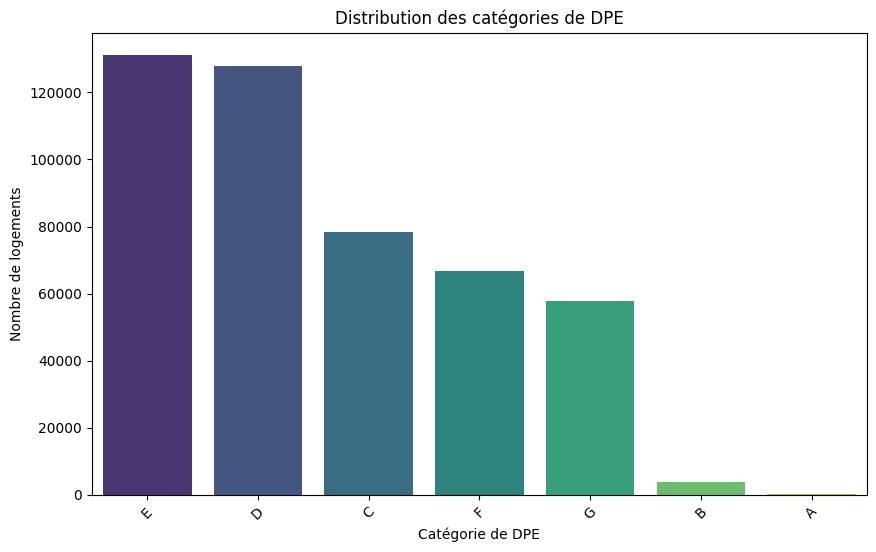

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assurer que la colonne existe et obtenir les valeurs uniques
dpe_column = 'Etiquette_DPE_ademe'  # Remplacer par la colonne exacte si nécessaire

if dpe_column in df.columns:
    # Calculer la fréquence des catégories DPE
    dpe_counts = df[dpe_column].value_counts()
    
    # Créer un graphique en barres
    plt.figure(figsize=(10, 6))
    sns.barplot(x=dpe_counts.index, y=dpe_counts.values, palette='viridis')
    
    # Ajouter les labels et le titre
    plt.xlabel('Catégorie de DPE')
    plt.ylabel('Nombre de logements')
    plt.title('Distribution des catégories de DPE')
    plt.xticks(rotation=45)
    
    # Afficher le graphique
    plt.show()
else:
    print(f"La colonne {dpe_column} n'existe pas dans les données.")


In [52]:
pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


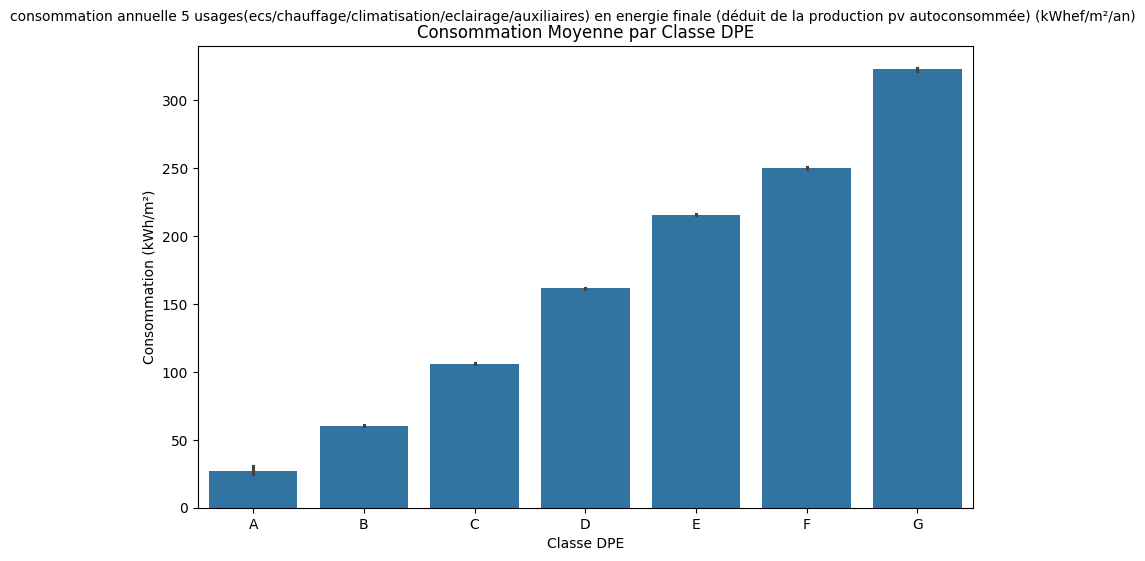

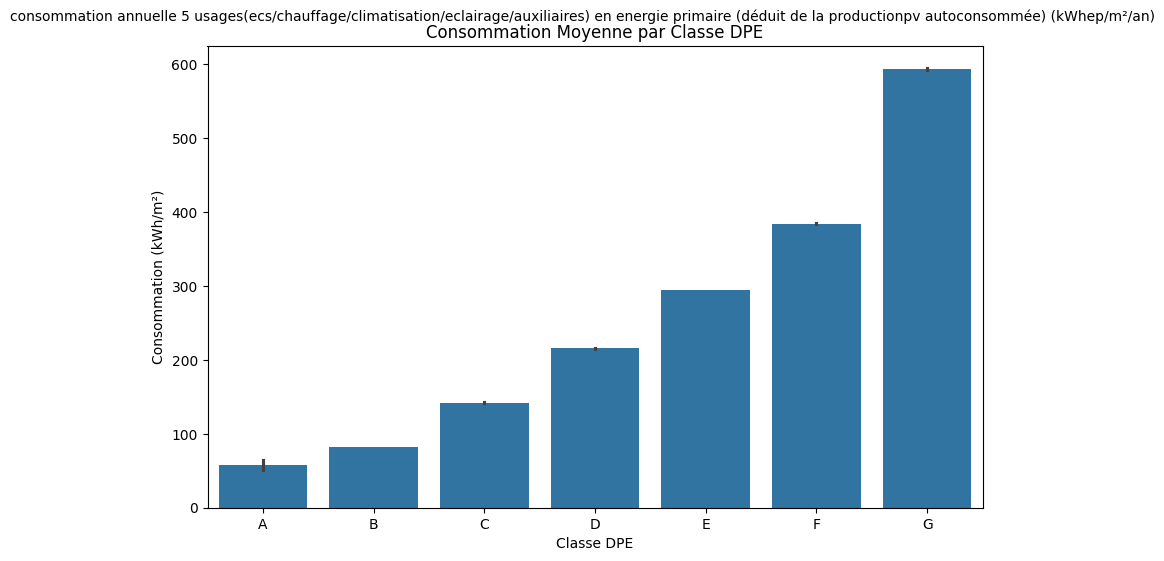

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger ton dataframe
# df_clean_col = pd.read_csv("ton_fichier.csv") # Remplace ton_fichier.csv

# 1. Consommation moyenne par classe DPE
plt.figure(figsize=(10, 6)) # Ajuste la taille
sns.barplot(x='Etiquette_DPE_ademe', y='Conso_5_usages/m²_é_finale_ademe', data=df_clean_col, order=sorted(df_clean_col['Etiquette_DPE_ademe'].unique())) # Tri pour l'ordre
plt.title('Consommation Moyenne par Classe DPE')
plt.suptitle('consommation annuelle 5 usages(ecs/chauffage/climatisation/eclairage/auxiliaires) en energie finale (déduit de la production pv autoconsommée) (kWhef/m²/an)', fontsize=10, y=0.94)
plt.xlabel('Classe DPE')
plt.ylabel('Consommation (kWh/m²)')
plt.show()

# 1. Consommation moyenne par classe DPE
plt.figure(figsize=(10, 6)) # Ajuste la taille
sns.barplot(x='Etiquette_DPE_ademe',  y='Conso_5_usages_par_m²_é_primaire_ademe', data=df_clean_col, order=sorted(df_clean_col['Etiquette_DPE_ademe'].unique())) # Tri pour l'ordre
plt.title('Consommation Moyenne par Classe DPE')
plt.suptitle('consommation annuelle 5 usages(ecs/chauffage/climatisation/eclairage/auxiliaires) en energie primaire (déduit de la productionpv autoconsommée) (kWhep/m²/an)', fontsize=10, y=0.94)
plt.xlabel('Classe DPE')
plt.ylabel('Consommation (kWh/m²)')
plt.show()


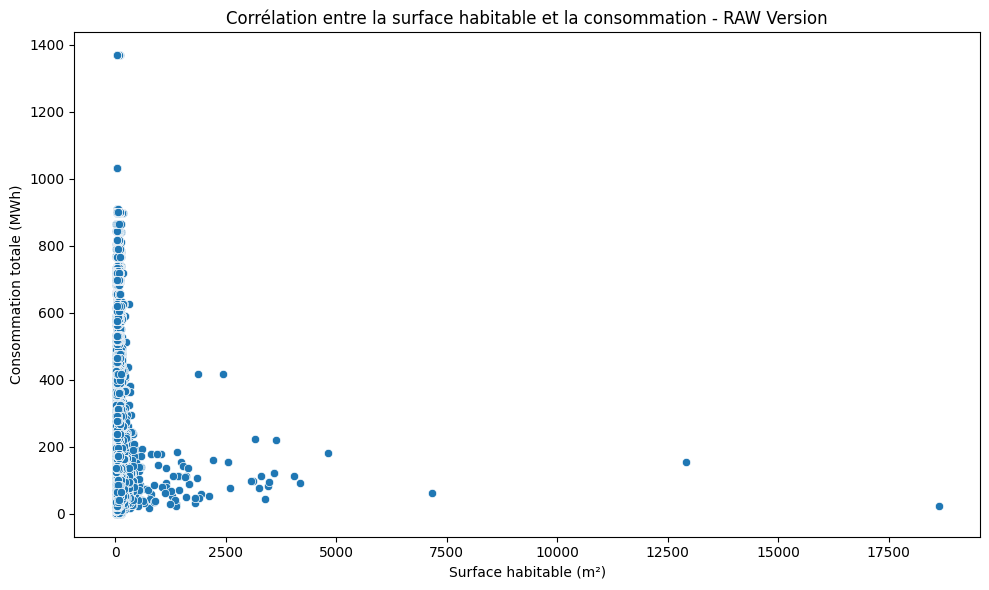

In [74]:

# 2. Corrélation entre la surface habitable et la consommation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean_col, x='Surface_habitable_logement_ademe', y='Consommation annuelle totale de l\'adresse (MWh)_enedis_with_ban')
plt.title("Corrélation entre la surface habitable et la consommation - RAW Version")
plt.xlabel("Surface habitable (m²)")
plt.ylabel("Consommation totale (MWh)")
plt.tight_layout()
plt.show()

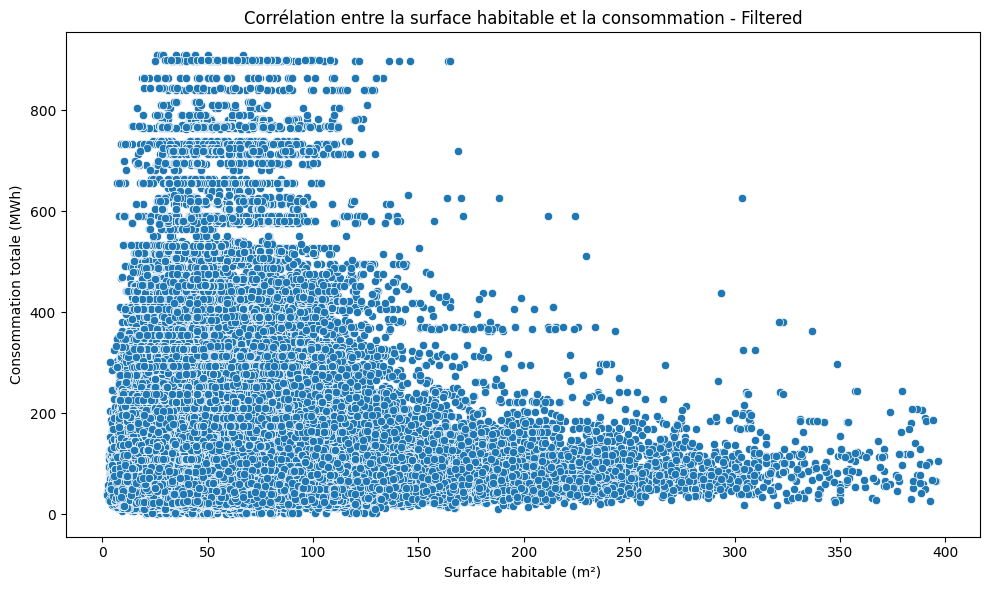

In [72]:
# Filtrer les données pour ne conserver que les surfaces inférieures à 5000m² et les consommations totales inférieures à 1000 MWh
df_filtered = df_clean_col[(df_clean_col['Surface_habitable_logement_ademe'] < 400) & 
                           (df_clean_col['Consommation annuelle totale de l\'adresse (MWh)_enedis_with_ban'] < 1000)]
# Créer le graphique
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Surface_habitable_logement_ademe', y='Consommation annuelle totale de l\'adresse (MWh)_enedis_with_ban')

# Ajouter le titre et les labels
plt.title("Corrélation entre la surface habitable et la consommation - Filtered")
plt.xlabel("Surface habitable (m²)")
plt.ylabel("Consommation totale (MWh)")

# Affiner la disposition
plt.tight_layout()

# Afficher le graphique
plt.show()


In [107]:
min_year = df_clean_col['Année_construction_ademe'].min()
max_year = df_clean_col['Année_construction_ademe'].max()

print(f"Année de construction la plus ancienne : {min_year}")
print(f"Année de construction la plus récente : {max_year}")


Année de construction la plus ancienne : 1400.0
Année de construction la plus récente : 2027.0


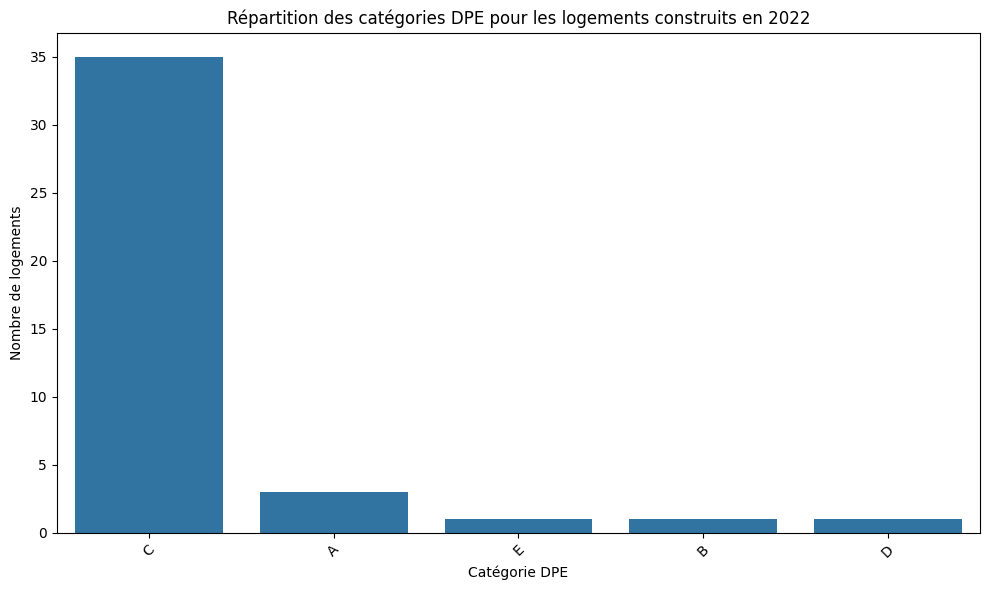

In [108]:
df_2022 = df_clean_col[df_clean_col['Année_construction_ademe'] == 2022]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_2022, x='Etiquette_DPE_ademe', order=df_2022['Etiquette_DPE_ademe'].value_counts().index)
plt.title("Répartition des catégories DPE pour les logements construits en 2022")
plt.xlabel("Catégorie DPE")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pickle

In [ ]:
!pip install unidecode


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os
os.getcwd()

'/Users/tharse/projet-dpe/CHALLENGE-DPE-OPENDATA-UNIV/notebooks'

In [ ]:
import sys, unidecode
sys.path.append('..')
from utils.fonctions import load_parquet_data

path = "../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet"
df = load_parquet_data(path)
df

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..


,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,nom_commune_ban_ademe,emission_ges_chauffage_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,cout_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,25827.1,0.0,2621.9,Paris,4670.2,0.0,2621.9,0,25827.1,1962.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
1,1318.3,100.0,1153.0,Paris,79.4,NaN,1153.0,0,1318.3,458.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
2,49222.4,100.0,1772.3,Paris,8796.8,3046.7,0.0,0,47488.7,3705.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
3,2468.6,100.0,1150.6,Paris,153.9,NaN,1150.6,0,2468.6,598.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
4,2526.3,100.0,1132.2,Paris,157.8,NaN,1132.2,0,2526.3,602.4,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464571,10005.5,0.0,1317.8,Paris,1848.5,0.0,1317.8,0,10005.5,1169.2,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address
464572,24006.5,0.0,1831.6,Paris,4459.3,0.0,1831.6,0,24006.5,2322.9,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address
464573,9978.5,70.0,1218.4,Paris,1831.3,1218.4,0.0,0,9978.5,1116.2,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address
464574,8399.9,0.0,1665.2,Paris,538.9,1665.2,0.0,0,8399.9,1363.0,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address


In [ ]:
import pickle
from utils.fonctions import normalize_name
from unidecode import unidecode

path = "../ressources/data/df_clean.pkl"
with open(path, 'rb') as f:
    colnames = pickle.load(f)
    colnames = list(map(lambda c: normalize_name(unidecode(c)).lower(), colnames))

In [ ]:
df = df[[c for c in colnames if c in df.columns]]

In [ ]:
df

,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,configuration_installation_chauffage_ndeg1_ademe,configuration_installation_ecs_ademe,type_installation_chauffage_ndeg1_ademe,...,score_ban_ademe,type_energie_principale_ecs_ademe,annee_construction_ademe,categorie_enr_ademe,qualite_isolation_plancher_haut_toit_terrase_ademe,nombre_niveau_immeuble_ademe,appartement_non_visite_0_1_ademe,consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,type_enedis_with_ban
0,25827.1,0.0,2621.9,0.0,2621.9,0,25827.1,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Gaz naturel,NaN,None,None,NaN,None,78.292,4.350,housenumber
1,1318.3,100.0,1153.0,NaN,1153.0,0,1318.3,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
2,49222.4,100.0,1772.3,3046.7,0.0,0,47488.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
3,2468.6,100.0,1150.6,NaN,1150.6,0,2468.6,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
4,2526.3,100.0,1132.2,NaN,1132.2,0,2526.3,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464571,10005.5,0.0,1317.8,0.0,1317.8,0,10005.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber
464572,24006.5,0.0,1831.6,0.0,1831.6,0,24006.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber
464573,9978.5,70.0,1218.4,1218.4,0.0,0,9978.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Électricité,NaN,None,None,NaN,None,156.897,3.202,housenumber
464574,8399.9,0.0,1665.2,1665.2,0.0,0,8399.9,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber


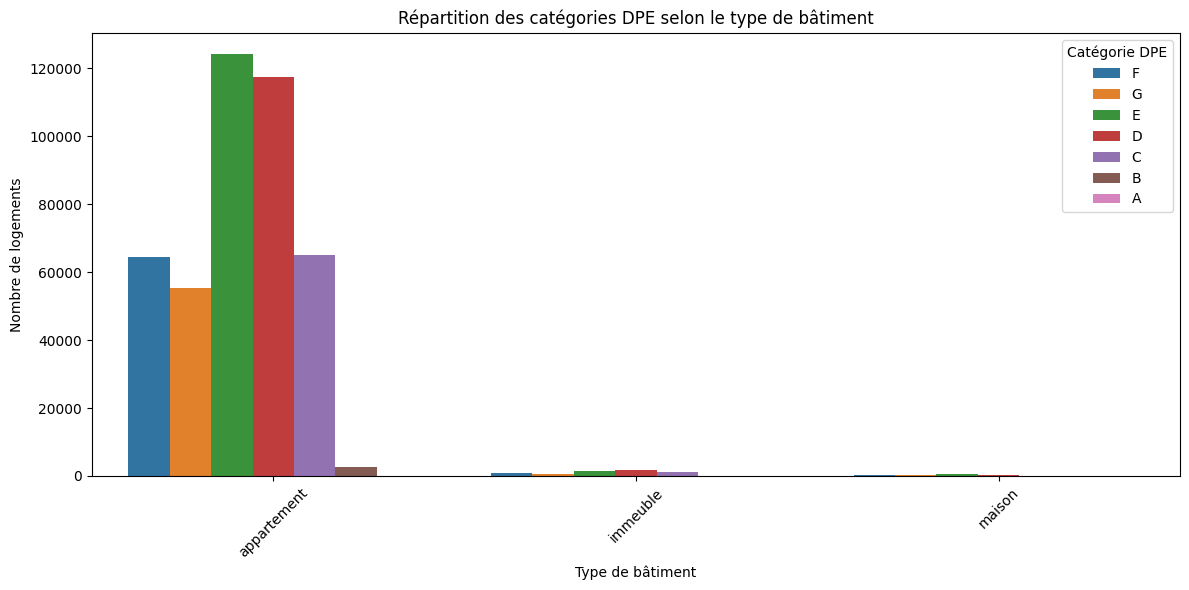

In [103]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean_col, x='Type_bâtiment_ademe', hue='Etiquette_DPE_ademe', order=df_clean_col['Type_bâtiment_ademe'].value_counts().index)
plt.title("Répartition des catégories DPE selon le type de bâtiment")
plt.xlabel("Type de bâtiment")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45)
plt.legend(title="Catégorie DPE", loc="upper right")
plt.tight_layout()
plt.show()

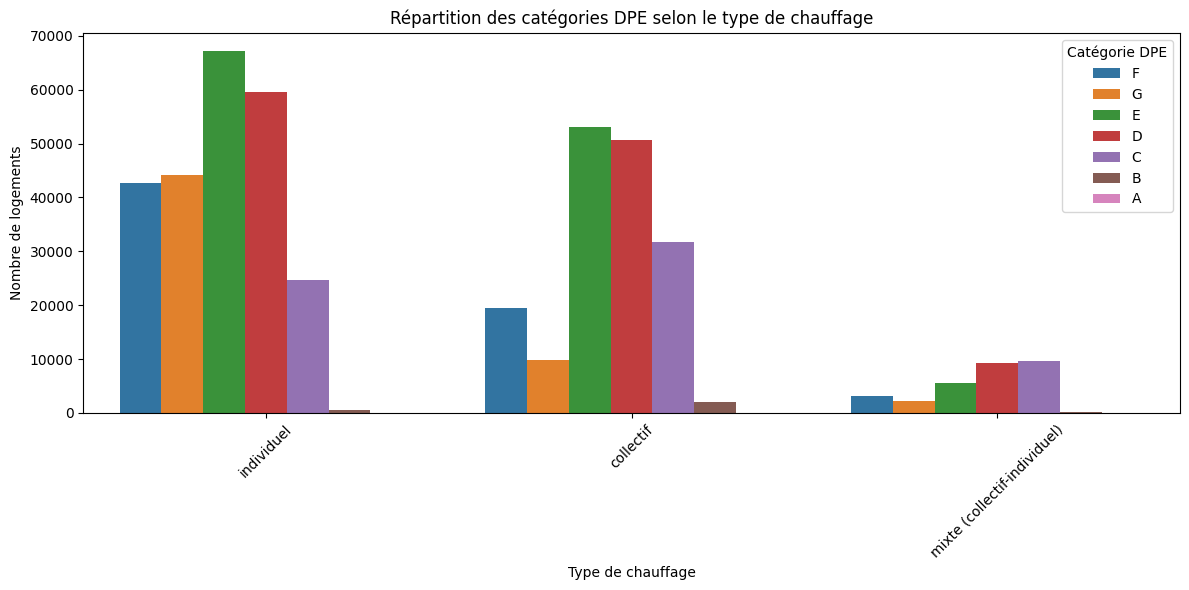

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean_col, x='Type_installation_chauffage_ademe', hue='Etiquette_DPE_ademe', order=df_clean_col['Type_installation_chauffage_ademe'].value_counts().index)
plt.title("Répartition des catégories DPE selon le type de chauffage")
plt.xlabel("Type de chauffage")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45)
plt.legend(title="Catégorie DPE", loc="upper right")
plt.tight_layout()
plt.show()

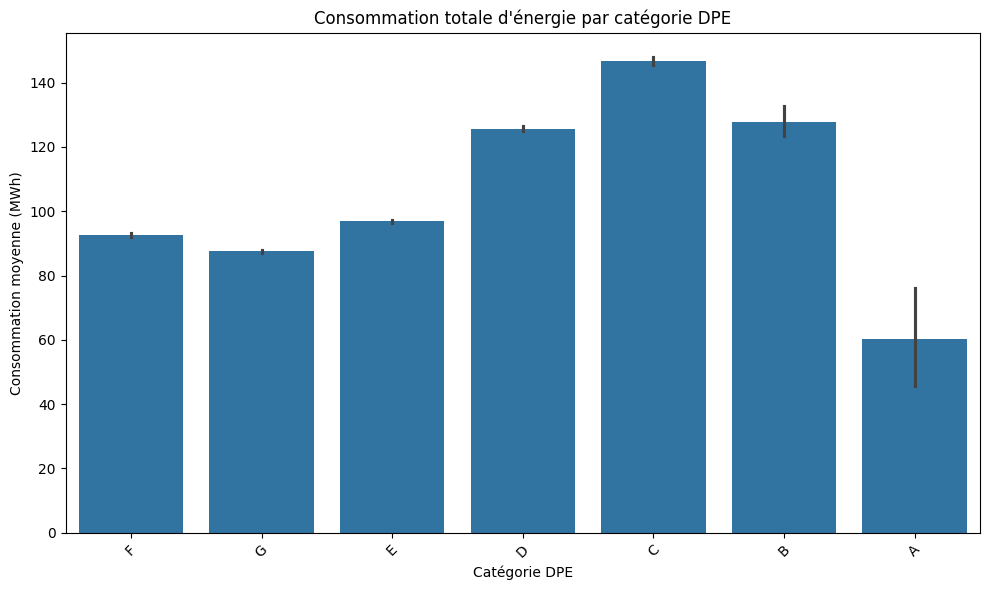

In [84]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean_col, x='Etiquette_DPE_ademe', y='Consommation annuelle totale de l\'adresse (MWh)_enedis_with_ban', estimator=np.mean)
plt.title("Consommation totale d'énergie par catégorie DPE")
plt.xlabel("Catégorie DPE")
plt.ylabel("Consommation moyenne (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


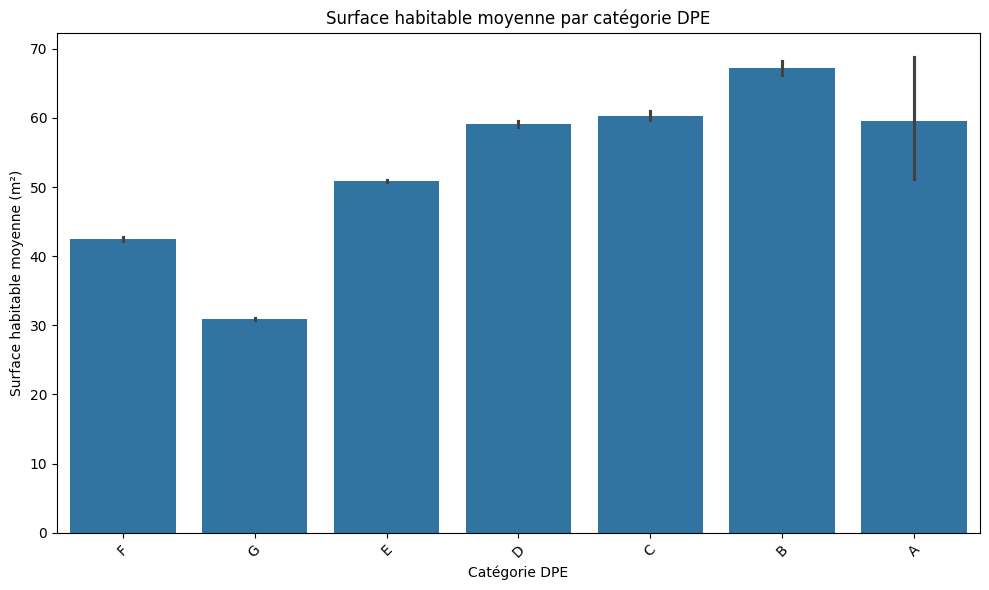

In [86]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean_col, x='Etiquette_DPE_ademe', y='Surface_habitable_logement_ademe', estimator=np.mean)
plt.title("Surface habitable moyenne par catégorie DPE")
plt.xlabel("Catégorie DPE")
plt.ylabel("Surface habitable moyenne (m²)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


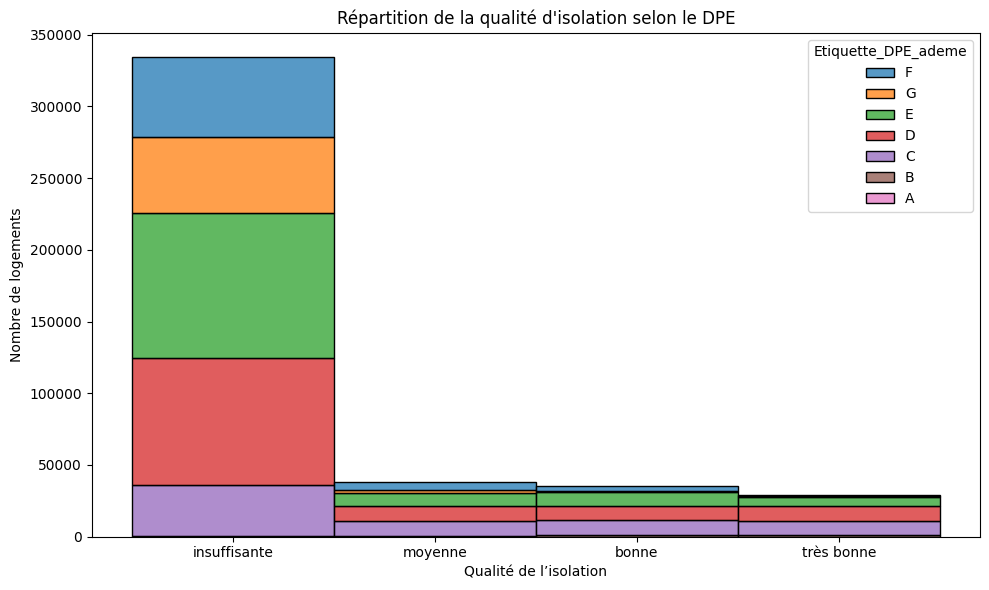

In [87]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean_col, x='Qualité_isolation_enveloppe_ademe', hue='Etiquette_DPE_ademe', multiple="stack", bins=10)
plt.title("Répartition de la qualité d'isolation selon le DPE")
plt.xlabel("Qualité de l’isolation")
plt.ylabel("Nombre de logements")
plt.tight_layout()
plt.show()


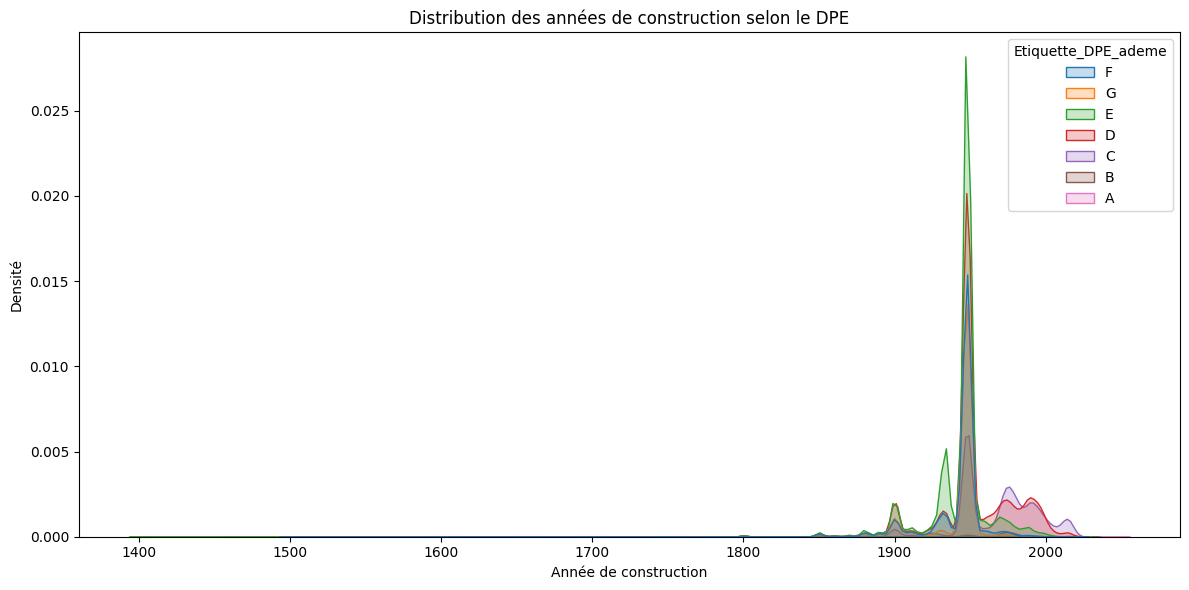

In [88]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_clean_col, x='Année_construction_ademe', hue='Etiquette_DPE_ademe', fill=True)
plt.title("Distribution des années de construction selon le DPE")
plt.xlabel("Année de construction")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()


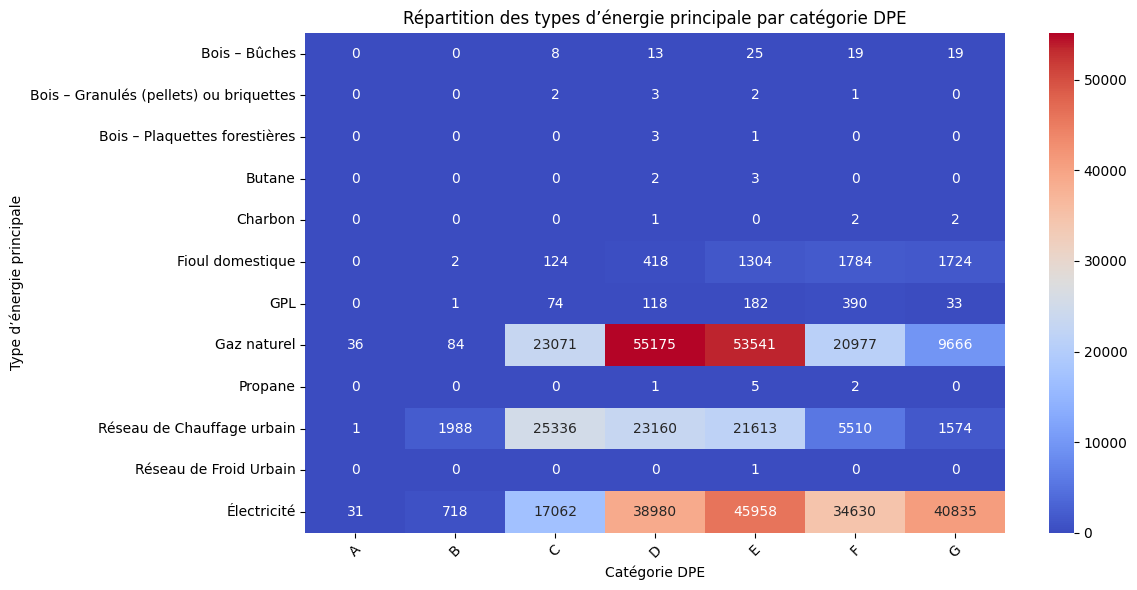

In [89]:
plt.figure(figsize=(12, 6))
heatmap_data = pd.crosstab(df_clean_col['Type_énergie_principale_chauffage_ademe'], df_clean_col['Etiquette_DPE_ademe'])
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt='d')
plt.title("Répartition des types d’énergie principale par catégorie DPE")
plt.xlabel("Catégorie DPE")
plt.ylabel("Type d’énergie principale")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


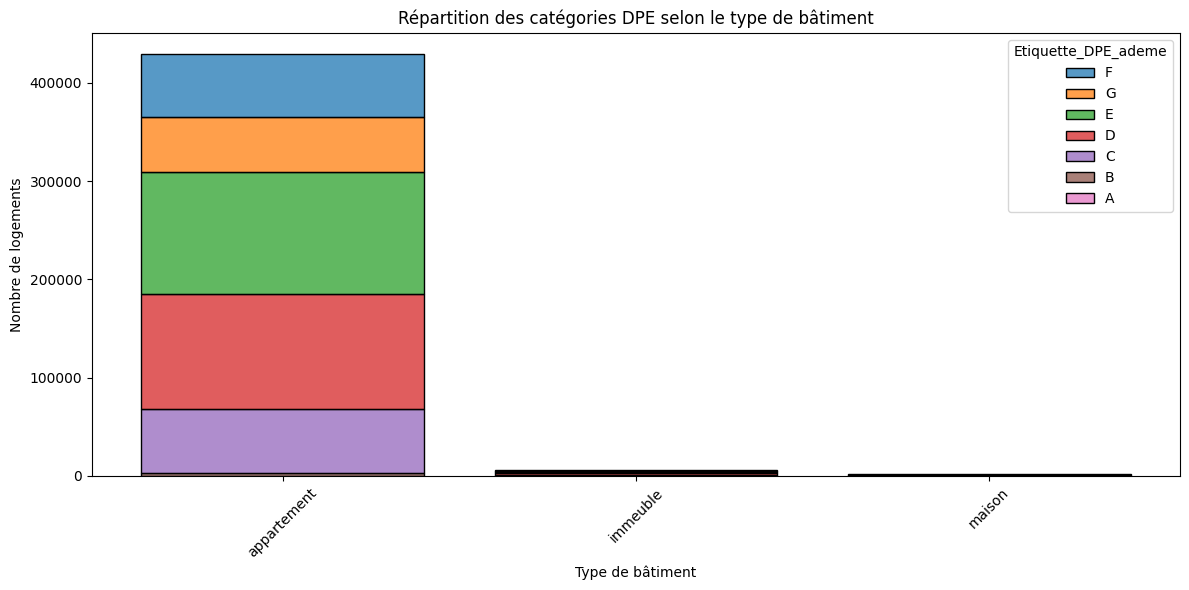

In [90]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean_col, x='Type_bâtiment_ademe', hue='Etiquette_DPE_ademe', multiple="stack", shrink=0.8)
plt.title("Répartition des catégories DPE selon le type de bâtiment")
plt.xlabel("Type de bâtiment")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


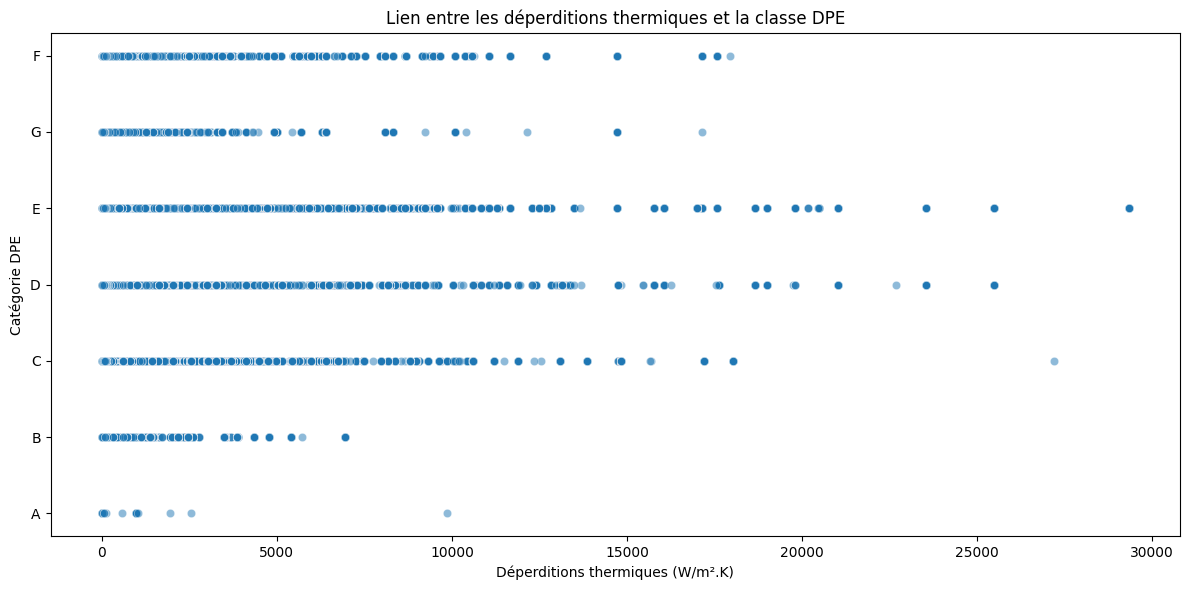

In [91]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_clean_col, x='Déperditions_renouvellement_air_ademe', y='Etiquette_DPE_ademe', alpha=0.5)
plt.title("Lien entre les déperditions thermiques et la classe DPE")
plt.xlabel("Déperditions thermiques (W/m².K)")
plt.ylabel("Catégorie DPE")
plt.tight_layout()
plt.show()


In [111]:
import numpy as np
import pandas as pd

def detect_outliers_large_columns(df, threshold=1.5, min_non_null_values=500):
    """
    Détecte les outliers uniquement dans les colonnes avec beaucoup de valeurs non nulles.
    Affiche les colonnes concernées avec la plus petite, la plus grande valeur et la moyenne.

    :param df: DataFrame Pandas
    :param threshold: Seuil pour détecter les outliers (1.5 = méthode standard)
    :param min_non_null_values: Nombre minimum de valeurs non nulles pour inclure une colonne
    :return: DataFrame formaté avec les stats des colonnes contenant des outliers
    """
    outliers_info = []

    # Sélectionner uniquement les colonnes numériques avec un grand nombre de valeurs non nulles
    large_columns = [col for col in df.select_dtypes(include=[np.number]).columns if df[col].count() > min_non_null_values]

    for col in large_columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1  # Intervalle interquartile

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not outliers.empty:  # S'il y a des outliers, on ajoute les stats
            outliers_info.append({
                "📌 Colonne": col,
                "📊 Nb Outliers": f"{len(outliers):,}",  # Format avec séparateurs de milliers
                "🔽 Min": f"{df[col].min():,.2f}",
                "🔼 Max": f"{df[col].max():,.2f}",
                "📈 Moyenne": f"{df[col].mean():,.2f}"
            })

    # Création du DataFrame de sortie trié par nombre d'outliers
    outliers_df = pd.DataFrame(outliers_info).sort_values(by="📊 Nb Outliers", ascending=False)

    # Affichage propre
    if outliers_df.empty:
        print("✅ Aucune colonne avec des outliers détectée.")
    else:
        from IPython.display import display  # Pour afficher le tableau proprement dans Jupyter Notebook
        display(outliers_df)

    return outliers_df

# Utilisation de la fonction sur ton DataFrame
outliers_df = detect_outliers_large_columns(df_clean_col, min_non_null_values=500)


,📌 Colonne,📊 Nb Outliers,🔽 Min,🔼 Max,📈 Moyenne
36,Emission_GES_5_usages_énergie_n°2_ademe,"97,226",0.00,"166,466.90",139.51
10,Surface_chauffée_installation_chauffage_n°1_ademe,"93,616",0.30,"39,182.00","1,539.84"
27,Surface_habitable_immeuble_ademe,"93,487",1.00,"65,470,000.00","5,423.04"
87,Conso_5_usages/m²_é_finale_ademe,"9,905",0.50,"7,690.90",202.26
76,Conso_5_usages_é_finale_énergie_n°2_ademe,"89,986",0.70,"877,816.80","1,342.12"
...,...,...,...,...,...
53,Coût_ECS_énergie_n°1_ademe,"14,991",0.00,"192,213.00",332.26
47,Emission_GES_chauffage_énergie_n°2_ademe,"14,854",0.00,"161,611.20",65.09
43,Surface_habitable_logement_ademe,"13,394",2.40,"18,637.00",50.81
97,Nombre_niveau_immeuble_ademe,"126,148",1.00,66.00,8.20


In [119]:
min_year = df_clean_col['Surface_habitable_logement_ademe'].min()
max_year = df_clean_col['Surface_habitable_logement_ademe'].max()

print(f"Min: {min_year}")
print(f"Max : {max_year}")

df_clean_col['Surface_habitable_logement_ademe'].describe()



Min: 2.4
Max : 18637.0


count    437073.000000
mean         50.809931
std          54.273352
min           2.400000
25%          29.000000
50%          44.900000
75%          64.600000
max       18637.000000
Name: Surface_habitable_logement_ademe, dtype: float64

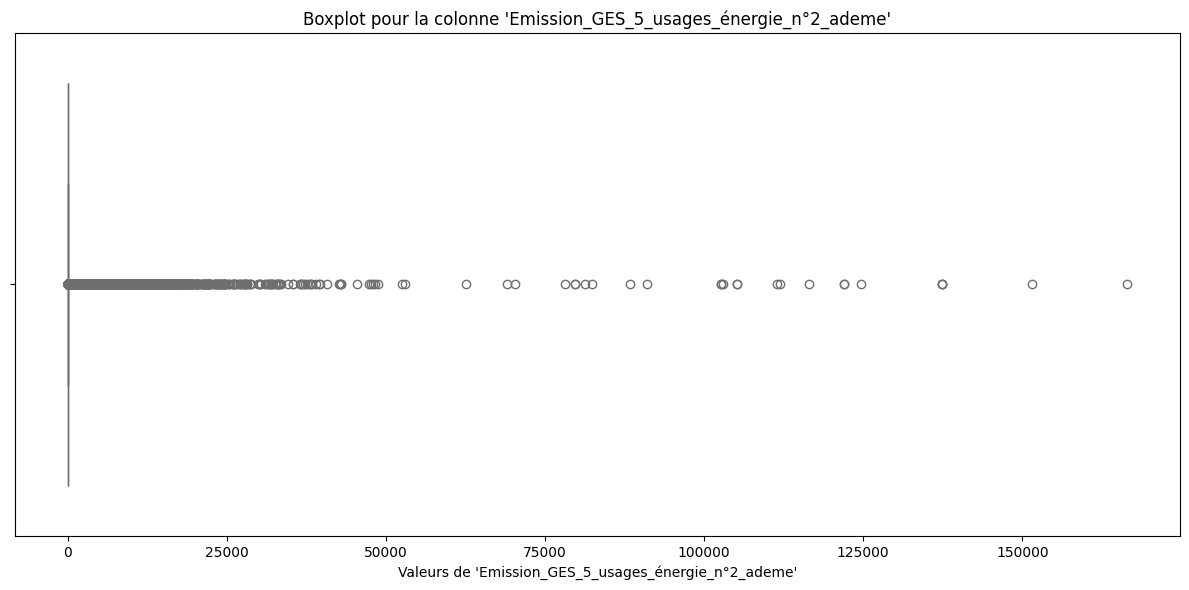

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_boxplot_for_column(df, column_name):
    """
    Crée un boxplot simple pour une colonne spécifique afin de visualiser la distribution et les outliers.

    :param df: DataFrame Pandas
    :param column_name: Nom de la colonne à analyser
    """
    # Création du boxplot
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=column_name, color='skyblue')

    # Ajouter un titre
    plt.title(f"Boxplot pour la colonne '{column_name}'")
    plt.xlabel(f"Valeurs de '{column_name}'")

    # Afficher le graphique
    plt.tight_layout()
    plt.show()

# Utilisation pour la colonne 'Emission_GES_5_usages_énergie_n°2_ademe'
plot_boxplot_for_column(df_clean_col, 'Emission_GES_5_usages_énergie_n°2_ademe')


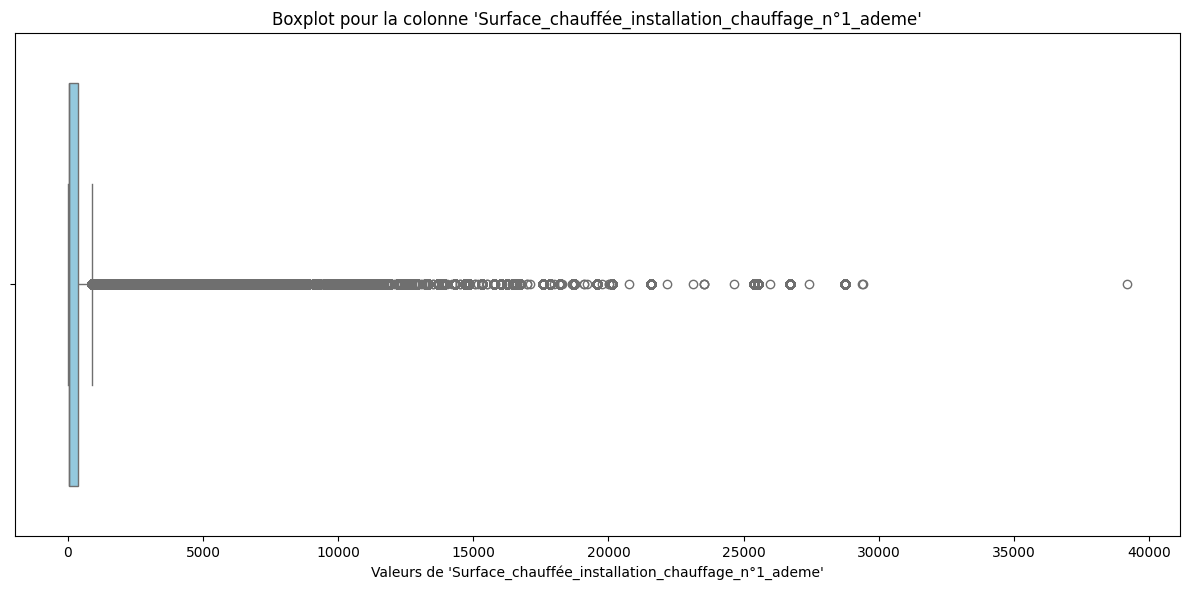

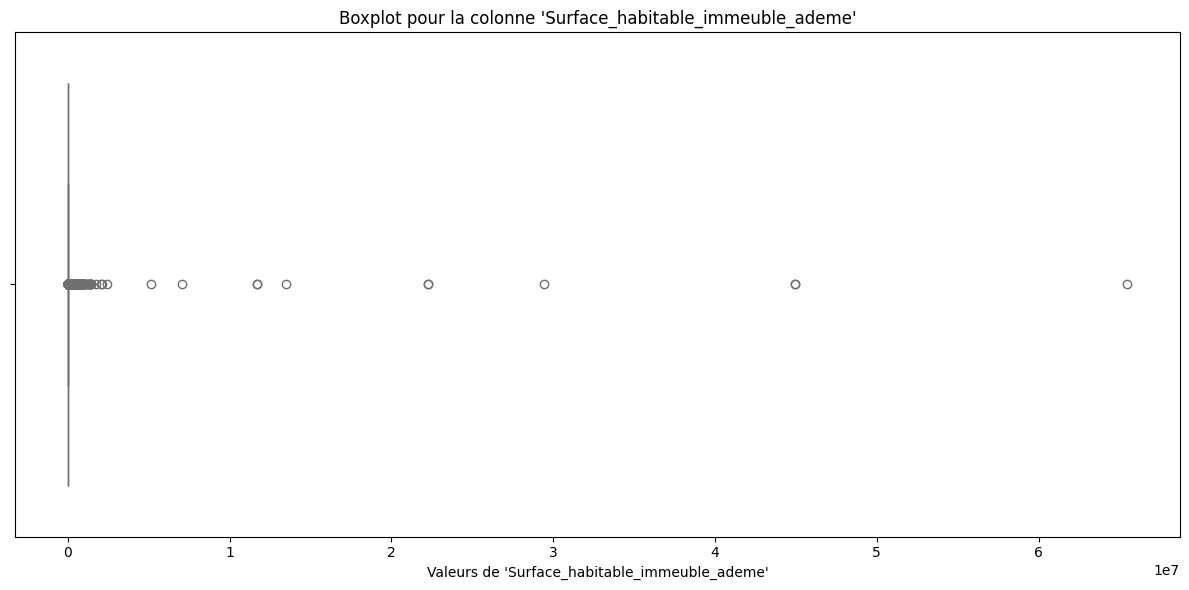

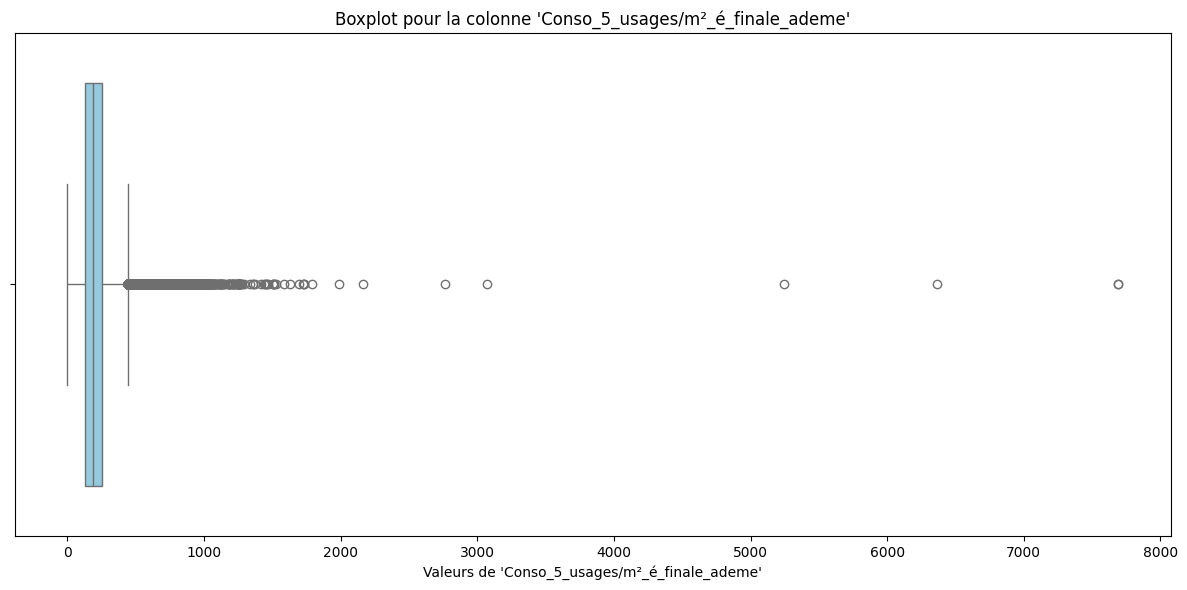

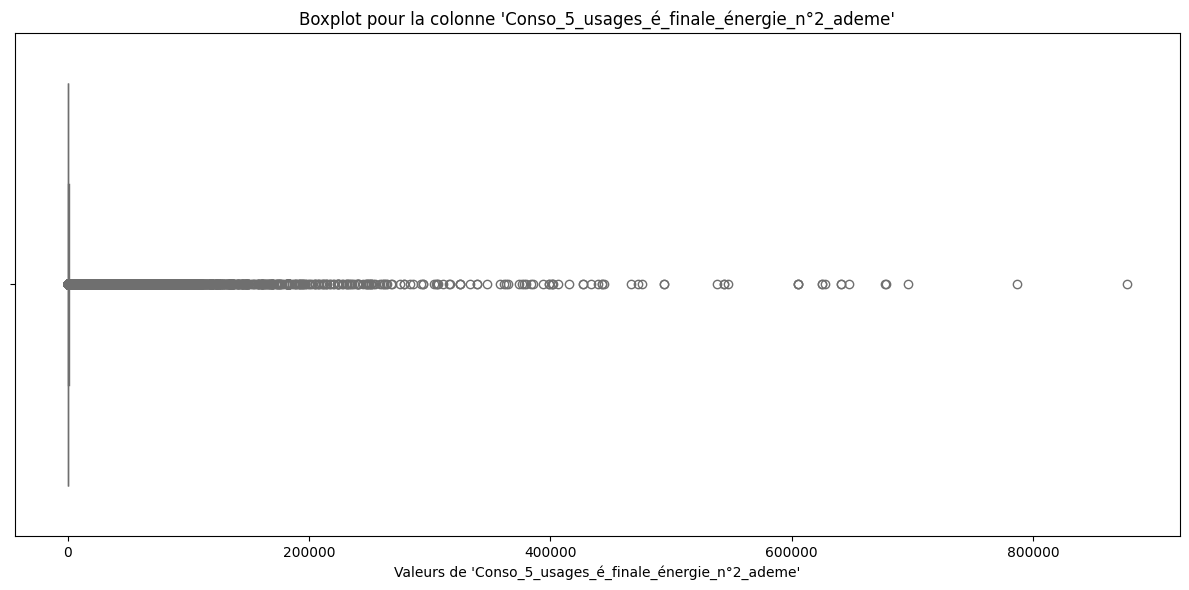

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_multiple_boxplots(df, columns):
    """
    Crée un boxplot pour plusieurs colonnes spécifiques afin de visualiser la distribution et les outliers.
    
    :param df: DataFrame Pandas
    :param columns: Liste des noms de colonnes à analyser
    """
    # Création d'un graphique pour chaque colonne dans la liste
    for column_name in columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df, x=column_name, color='skyblue')

        # Ajouter un titre
        plt.title(f"Boxplot pour la colonne '{column_name}'")
        plt.xlabel(f"Valeurs de '{column_name}'")

        # Afficher le graphique
        plt.tight_layout()
        plt.show()

# Liste des colonnes à analyser
columns_to_analyze = [
    'Surface_chauffée_installation_chauffage_n°1_ademe',
    'Surface_habitable_immeuble_ademe',
    'Conso_5_usages/m²_é_finale_ademe',
    'Conso_5_usages_é_finale_énergie_n°2_ademe'
]

# Utilisation de la fonction pour afficher les boxplots
plot_multiple_boxplots(df_clean_col, columns_to_analyze)


In [28]:
# garder l'arrondissement
import re
def extract_digit(x):
    return re.sub(r'\D', '', str(x))

df["arrondissement"] = df["district_enedis_with_ban"].apply(extract_digit).astype('string')

KeyError: 'district_enedis_with_ban'

In [ ]:
to_drop = ["district_enedis_with_ban","street_enedis_with_ban", "name_enedis_with_ban", "id_BAN_enedis_with_ban", "housenumber_enedis_with_ban", "label_enedis_with_ban", "full_adress_enedis_with_ban",
           "adresse_enedis_with_ban","Libellé de voie_enedis_with_ban", "Type de voie_enedis_with_ban", "Nom IRIS_enedis_with_ban", "N°_DPE_immeuble_associé_ademe", "Nom__rue_(BAN)_ademe",
           "Identifiant__BAN_ademe","Complément_d'adresse_bâtiment_ademe", "Adresse_brute_ademe", "N°DPE_ademe", "N°_voie_(BAN)_ademe", "Complément_d'adresse_logement_ademe",
           "Adresse_(BAN)_ademe","_geopoint_ademe","Statut_géocodage_ademe", "Description_installation_ECS_ademe", "Description_générateur_ECS_n°1_ademe",
           "Description_générateur_chauffage_n°1_installation_n°1_ademe", "Description_installation_chauffage_n°1_ademe", "score_enedis_with_ban", "x_enedis_with_ban", "y_enedis_with_ban","importance_enedis_with_ban"]

df_clean.drop(to_drop, axis=1, inplace=True)
print(f'il reste {len(df_clean.columns)} colonnes')

il reste 88 colonnes


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 437073 entries, 0 to 465960
Data columns (total 88 columns):
 #   Column                                                                         Non-Null Count   Dtype  
---  ------                                                                         --------------   -----  
 0   Conso_chauffage_dépensier_é_finale_ademe                                       437073 non-null  float64
 1   Volume_stockage_générateur_ECS_n°1_ademe                                       437073 non-null  float64
 2   Conso_é_finale_installation_ECS_ademe                                          437073 non-null  float64
 3   Conso_ECS_é_finale_énergie_n°2_ademe                                           437073 non-null  float64
 4   Conso_ECS_é_finale_énergie_n°1_ademe                                           437073 non-null  float64
 5   Besoin_refroidissement_ademe                                                   437073 non-null  float64
 6   Conso_chauffage_d

In [ ]:
df_clean['Type_installation_chauffage_n°1_ademe'].value_counts()

Type_installation_chauffage_n°1_ademe
installation individuelle                                                                                       244392
installation collective                                                                                         160068
installation collective multi-bâtiment : modélisée comme un réseau de chaleur                                    19410
installation hybride collective-individuelle (chauffage base + appoint individuel ou convecteur bi-jonction)      2112
Name: count, dtype: Int64

In [ ]:
df_clean['Type_installation_chauffage_ademe'].value_counts()

Type_installation_chauffage_ademe
individuel                      238822
collectif                       166610
mixte (collectif-individuel)     30053
Name: count, dtype: Int64

In [25]:
df

,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,configuration_installation_chauffage_ndeg1_ademe,configuration_installation_ecs_ademe,type_installation_chauffage_ndeg1_ademe,...,score_ban_ademe,type_energie_principale_ecs_ademe,annee_construction_ademe,categorie_enr_ademe,qualite_isolation_plancher_haut_toit_terrase_ademe,nombre_niveau_immeuble_ademe,appartement_non_visite_0_1_ademe,consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,type_enedis_with_ban
0,25827.1,0.0,2621.9,0.0,2621.9,0,25827.1,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Gaz naturel,NaN,None,None,NaN,None,78.292,4.350,housenumber
1,1318.3,100.0,1153.0,NaN,1153.0,0,1318.3,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
2,49222.4,100.0,1772.3,3046.7,0.0,0,47488.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
3,2468.6,100.0,1150.6,NaN,1150.6,0,2468.6,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
4,2526.3,100.0,1132.2,NaN,1132.2,0,2526.3,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464571,10005.5,0.0,1317.8,0.0,1317.8,0,10005.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber
464572,24006.5,0.0,1831.6,0.0,1831.6,0,24006.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber
464573,9978.5,70.0,1218.4,1218.4,0.0,0,9978.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Électricité,NaN,None,None,NaN,None,156.897,3.202,housenumber
464574,8399.9,0.0,1665.2,1665.2,0.0,0,8399.9,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber


In [ ]:
from sklearn.preprocessing import LabelBinarizer
#Inertie_lourde_(0/1)_ademe,Logement_traversant_(0/1)_ademe,Présence_brasseur_air_(0/1)_ademe,Protection_solaire_exterieure_(0/1)_ademe,Logement_traversant_(0/1)_ademe,Isolation_toiture_(0/1)_ademe,Appartement_non_visité_(0/1)_ademe
lb = LabelBinarizer()
lb.fit_transform()

In [ ]:
# encoding
#for col in df_clean.columns:
    #print(col)
    # print(df_clean[col].value_counts())

# Configuration_installation_chauffage_n°1_ademe, Configuration_installation_ECS_ademe, 
# Type_installation_chauffage_n°1_ademe, Type_installation_ECS_(général)_ademe
# Usage_générateur_ECS_n°1_ademe, N°_étage_appartement_ademe, Type_énergie_générateur_ECS_n°1_ademe,
# Type_générateur_ECS_n°1_ademe, ,ualité_isolation_menuiseries_ademe,
# Qualité_isolation_murs_ademe, Type_émetteur_installation_chauffage_n°1_ademe,
# Méthode_application_DPE_ademe, Période_construction_ademe,Indicateur_confort_été_ademe,
# Type_énergie_n°1_ademe,Type_énergie_n°2_ademe, Type_installation_ECS_ademe,
# ,Qualité_isolation_plancher_haut_comble_perdu_ademe,
# Type_bâtiment_ademe,,Usage_générateur_n°1_installation_n°1_ademe,
# Version_DPE_ademe, Type_énergie_générateur_n°1_installation_n°1_ademe, Type_installation_chauffage_ademe,
# Type_énergie_principale_chauffage_ademe, ,Qualité_isolation_enveloppe_ademe,
# , Etiquette_GES_ademe,Etiquette_DPE_ademe,Type_générateur_n°1_installation_n°1_ademe,
# Qualité_isolation_plancher_bas_ademe,Type_énergie_principale_ECS_ademe, Année_construction_ademe,
# Catégorie_ENR_ademe,Qualité_isolation_plancher_haut_toit_terrase_ademe,
# , type_enedis_with_ban
import pickle
with open(r'/Users/carla/Desktop/GitHub/CHALLENGE-DPE-OPENDATA-UNIV/ressources/data/df_clean_cols.txt', 'w') as f :
    for col in df_clean.columns:
        f.write(col + '\n')

pickle.dump(df_clean.columns, open('/Users/carla/Desktop/GitHub/CHALLENGE-DPE-OPENDATA-UNIV/ressources/data/df_clean.pkl', 'wb'))



In [ ]:
len(df_clean.columns)
df_clean.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Configuration_installation_chauffage_n°1_ademe,Configuration_installation_ECS_ademe,Type_installation_chauffage_n°1_ademe,...,Type_énergie_principale_ECS_ademe,Année_construction_ademe,Catégorie_ENR_ademe,Qualité_isolation_plancher_haut_toit_terrase_ademe,Nombre_niveau_immeuble_ademe,Appartement_non_visité_(0/1)_ademe,Consommation annuelle totale de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban,type_enedis_with_ban,arrondissement
0,16170.8,0.0,1548.3,0.0,1548.3,0.0,16170.8,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,23.715,1.694,housenumber,17
1,20081.5,0.0,5617.0,0.0,5617.0,0.0,20081.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,23.715,1.694,housenumber,17
2,38501.7,0.0,5812.1,0.0,5812.1,0.0,38501.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Fioul domestique,1948.0,<NA>,<NA>,8.0,<NA>,41.505,2.965,housenumber,16
3,39468.7,0.0,6130.1,0.0,6130.1,0.0,39468.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Fioul domestique,1948.0,<NA>,<NA>,8.0,<NA>,41.505,2.965,housenumber,16
4,15376.1,0.0,5752.4,0.0,5752.4,0.0,15376.1,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16


In [ ]:
round(df_clean["Type_bâtiment_ademe"].value_counts(normalize=True, dropna = False),2)

Type_bâtiment_ademe
appartement    0.98
immeuble       0.01
maison          0.0
Name: proportion, dtype: Float64

In [ ]:
round(df_clean["Etiquette_DPE_ademe"].value_counts(normalize=True, dropna = False),3)

Etiquette_DPE_ademe
E    0.289
D    0.274
C    0.151
F     0.15
G    0.129
B    0.006
A      0.0
Name: proportion, dtype: Float64

In [ ]:
# from scipy.stats import chi2_contingency

# def clean_chi2(df):
#     indep_features = []
#     #x = df.drop("Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban", axis=1)

#     # Étape 1 : Création d'un tableau croisé pour deux variables
#     for c in df.drop("Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban", axis=1).columns:
#         print(c)
#         contingency_table = pd.crosstab(df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"], df[c])

#         # Étape 2 : Test du chi-carré
#         chi2, p, dof, expected = chi2_contingency(contingency_table)

#         # Affichage des résultats
#         print("\np-valeur :", p)

#         # Interprétation
#         if p < 0.05:
#             print("\nLa variable {} est dépendante (relation significative).".format(str(c)))
#         else:
#             print("\nLa variable {} est indépendante (pas de relation significative).".format(str(c)))
#             indep_features.append(c)

#     df.drop(columns=indep_features, inplace=True, axis=1)
#     print("le nombre de colonnes finales \n:",len(df.columns))
#     return df

# test_clean_chi2 = clean_chi2(test_clean)

Conso_chauffage_dépensier_é_finale_ademe

p-valeur : 0.0

La variable Conso_chauffage_dépensier_é_finale_ademe est dépendante (relation significative).
Volume_stockage_générateur_ECS_n°1_ademe

p-valeur : 0.0

La variable Volume_stockage_générateur_ECS_n°1_ademe est dépendante (relation significative).
Conso_é_finale_installation_ECS_ademe

p-valeur : 0.0

La variable Conso_é_finale_installation_ECS_ademe est dépendante (relation significative).
Conso_ECS_é_finale_énergie_n°2_ademe

p-valeur : 0.0

La variable Conso_ECS_é_finale_énergie_n°2_ademe est dépendante (relation significative).
Conso_ECS_é_finale_énergie_n°1_ademe

p-valeur : 0.0

La variable Conso_ECS_é_finale_énergie_n°1_ademe est dépendante (relation significative).
Besoin_refroidissement_ademe

p-valeur : 0.0

La variable Besoin_refroidissement_ademe est dépendante (relation significative).
Conso_chauffage_dépensier_installation_chauffage_n°1_ademe

p-valeur : 0.0

La variable Conso_chauffage_dépensier_installation_chauffa

: 

In [ ]:
# nettoyage des outliers

# col_fill_median = []
# col_fill_mean = []
# for col in df.select_dtypes(['int','float']).columns:
#     #print(col)
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     # print(IQR, Q1-1.5*IQR, Q3+1.5*IQR)
#     # data_clean = data_clean[~((data_clean[col]<(Q1-1.5*IQR))|(data_clean[col]>(Q3+1.5*IQR)))]
#     # print((df[col]<(Q1-1.5*IQR)).value_counts(), (df[col]>(Q3+1.5*IQR)).value_counts())
#     born_inf =(df[col]<(Q1-1.5*IQR)).value_counts()
#     born_sup = (df[col]>(Q3+1.5*IQR)).value_counts()
#     try:
#         born_inf[1]
#         col_fill_median.append(col)
#     except Exception as e:
#         try:
#             born_sup[1]
#             col_fill_median.append(col)
#         except Exception as e:
#             # print("il n'y a que des False")
#             col_fill_mean.append(col)
# # print("le nomnbre de colonnes traitées:", len(df.select_dtypes(['int','float']).columns))
# # print(len(col_fill_median))
# # print(len(col_fill_mean))
# for col in df.select_dtypes(['int','float']).columns:
#     if col in col_fill_mean:
#         df[col].fillna(df[col].mean, inplace=True)
#     if col in col_fill_median:
#         df[col].fillna(df[col].median, inplace=True)
#     else:
#         print(col)
#         # print("il y a un probleme")



_rand_ademe
Année_enedis_with_ban
code_commune_enedis_with_ban
Consommation annuelle moyenne de la commune (MWh)_enedis_with_ban
Code EPCI_enedis_with_ban
Code Département_enedis_with_ban
Code Région_enedis_with_ban
Tri des adresses_enedis_with_ban
x_enedis_with_ban
y_enedis_with_ban
lon_enedis_with_ban
lat_enedis_with_ban


In [ ]:
# # recherches des valeurs manquantes
# def get_entropy(pk, L):
#     op = - (pk * np.log(pk) / np.log(L)).sum()
#     return op

# tauxseuil = 0.9
# nanames = []
# entro = []
# extra =[]
# print("Le dataframe contient initialement {} colonnes et {}".format(len(df.columns), len(df)))
# for c in df.columns:
#     tauxnan = round(df[c].isna().sum()/len(df),2)
#     pk = df[c].value_counts(normalize=True, dropna = False).values
#     entropy = round(get_entropy(pk, len(df)),2)
#     if tauxnan >= tauxseuil:
#         nanames.append(c)
#     if c[0]=="_" and "geo" not in c:
#         #print(c)
#         extra.append(c)
#         #print("***", c, "***")
#         #print(tauxnan)
#     if entropy == 1 or entropy == 0:
#         # print(c, entropy)
#         nanames.append(c)
#         entro.append(c)
# print("Il y a {} colonnes vides avec au moins {}% , {} colonnes avec une entropy de 1 ou 0 et {} colonnes inutiles.".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
# # print(len(df.columns))
# # print(nanames)
# df_clean = df.copy().drop(nanames+entro+extra, axis=1).drop_duplicates()
# print("Il reste {} colonnes et {} lignes.".format(len(df_clean.columns),len(df_clean)))

Le dataframe contient initialement 280 colonnes et 465961
_rand_ademe
_i_ademe
_score_ademe
_id_ademe
_type_enedis_with_ban
Il y a 131 colonnes vides avec au moins 90.0% , 55 colonnes avec une entropy de 1 ou 0 et 5 colonnes inutiles.
Il reste 183 colonnes et 437073 lignes.


In [ ]:
# import numpy as np
# def get_entropy(pk, L):
#         op = - (pk * np.log(pk) / np.log(L)).sum()
#         return op 
# # pk : probabilité de chaque valeur
# # L : nombre de valeurs possibles
# # d : dataframe
# # cols : liste des colonnes à traiter

# def compute_entropies(d, cols):
#     entropies = []
#     for i,col in enumerate(cols):
#         pk = d[col].value_counts(normalize=True, dropna = False).values
#         entropy = round(get_entropy(pk, len(d)),3)
#         entropies.append({"col": col, "entropy": entropy})
#     return entropies      

# df_entropy = pd.DataFrame(compute_entropies(df_clean, df_clean.columns))

In [ ]:
# df_entropy.sort_values(by="entropy", ascending=True).head(50)

,col,entropy
177,type_enedis_with_ban,0.004
76,Emission_GES_refroidissement_ademe,0.007
96,Type_bâtiment_ademe,0.007
95,Emission_GES_refroidissement_dépensier_ademe,0.008
20,Coût_refroidissement_ademe,0.008
65,Conso_refroidissement_é_primaire_ademe,0.009
92,Coût_refroidissement_dépensier_ademe,0.009
46,Conso_refroidissement_é_finale_ademe,0.009
130,Conso_refroidissement_dépensier_é_primaire_ademe,0.010
105,Conso_refroidissement_dépensier_é_finale_ademe,0.010


Pickle

In [ ]:
!pip install unidecode


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os
os.getcwd()

'/Users/tharse/projet-dpe/CHALLENGE-DPE-OPENDATA-UNIV/notebooks'

In [ ]:
import sys, unidecode
sys.path.append('..')
from utils.fonctions import load_parquet_data

path = "../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet"
df = load_parquet_data(path)
df

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..


,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,nom_commune_ban_ademe,emission_ges_chauffage_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,cout_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,25827.1,0.0,2621.9,Paris,4670.2,0.0,2621.9,0,25827.1,1962.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
1,1318.3,100.0,1153.0,Paris,79.4,NaN,1153.0,0,1318.3,458.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
2,49222.4,100.0,1772.3,Paris,8796.8,3046.7,0.0,0,47488.7,3705.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
3,2468.6,100.0,1150.6,Paris,153.9,NaN,1150.6,0,2468.6,598.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
4,2526.3,100.0,1132.2,Paris,157.8,NaN,1132.2,0,2526.3,602.4,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.848740,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464571,10005.5,0.0,1317.8,Paris,1848.5,0.0,1317.8,0,10005.5,1169.2,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address
464572,24006.5,0.0,1831.6,Paris,4459.3,0.0,1831.6,0,24006.5,2322.9,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address
464573,9978.5,70.0,1218.4,Paris,1831.3,1218.4,0.0,0,9978.5,1116.2,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address
464574,8399.9,0.0,1665.2,Paris,538.9,1665.2,0.0,0,8399.9,1363.0,...,6862718.42,Paris,Paris 11e Arrondissement,"75, Paris, Île-de-France",housenumber,0.82447,Boulevard Voltaire,2.371325,48.862846,address


In [ ]:
import pickle
from utils.fonctions import normalize_name
from unidecode import unidecode

path = "../ressources/data/df_clean.pkl"
with open(path, 'rb') as f:
    colnames = pickle.load(f)
    colnames = list(map(lambda c: normalize_name(unidecode(c)).lower(), colnames))

In [ ]:
df = df[[c for c in colnames if c in df.columns]]

In [ ]:
df

,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,configuration_installation_chauffage_ndeg1_ademe,configuration_installation_ecs_ademe,type_installation_chauffage_ndeg1_ademe,...,score_ban_ademe,type_energie_principale_ecs_ademe,annee_construction_ademe,categorie_enr_ademe,qualite_isolation_plancher_haut_toit_terrase_ademe,nombre_niveau_immeuble_ademe,appartement_non_visite_0_1_ademe,consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,type_enedis_with_ban
0,25827.1,0.0,2621.9,0.0,2621.9,0,25827.1,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Gaz naturel,NaN,None,None,NaN,None,78.292,4.350,housenumber
1,1318.3,100.0,1153.0,NaN,1153.0,0,1318.3,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
2,49222.4,100.0,1772.3,3046.7,0.0,0,47488.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
3,2468.6,100.0,1150.6,NaN,1150.6,0,2468.6,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
4,2526.3,100.0,1132.2,NaN,1132.2,0,2526.3,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.72,Électricité,NaN,None,None,NaN,None,78.292,4.350,housenumber
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464571,10005.5,0.0,1317.8,0.0,1317.8,0,10005.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber
464572,24006.5,0.0,1831.6,0.0,1831.6,0,24006.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber
464573,9978.5,70.0,1218.4,1218.4,0.0,0,9978.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Électricité,NaN,None,None,NaN,None,156.897,3.202,housenumber
464574,8399.9,0.0,1665.2,1665.2,0.0,0,8399.9,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,...,0.83,Gaz naturel,NaN,None,None,NaN,None,156.897,3.202,housenumber


In [ ]:
for c in df_clean.select_dtypes("string").columns:
    # print(c,)
    print(df_clean[c].value_counts(), "\n")

Configuration_installation_chauffage_n°1_ademe
Installation de chauffage simple                                                                                                                         423566
Installation de chauffage collectif avec Base + appoint                                                                                                    1860
Convecteurs bi-jonction                                                                                                                                     294
Installation de chauffage avec insert ou poêle bois en appoint                                                                                              160
Installation de chauffage avec chaudière en relève de PAC                                                                                                    65
Installation de chauffage avec en appoint un insert ou poêle bois et un chauffage électrique dans la salle de bain (différent du chauffage principal)    

In [ ]:
for c in df_cleaned_float.columns:
    if "adresse_" in c.lower():
        print(c)

NameError: name 'df_cleaned_float' is not defined

<BarContainer object of 7 artists>

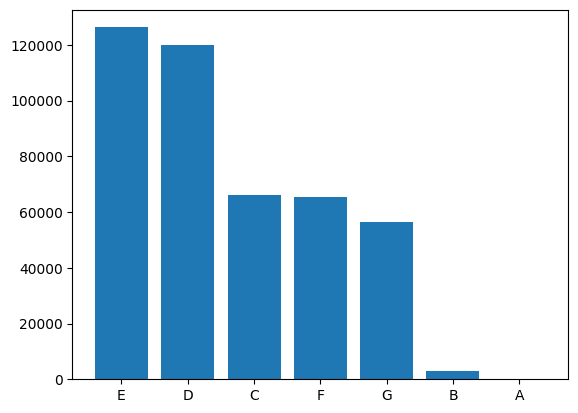

In [ ]:
# distribution des logements en fonction des DPE
import matplotlib.pyplot as plt
import numpy as np

DPE = df_clean["Etiquette_DPE_ademe"].value_counts().index
count = df_clean["Etiquette_DPE_ademe"].value_counts()
fig, ax = plt.subplots()
ax.bar(DPE,count)

<Axes: >

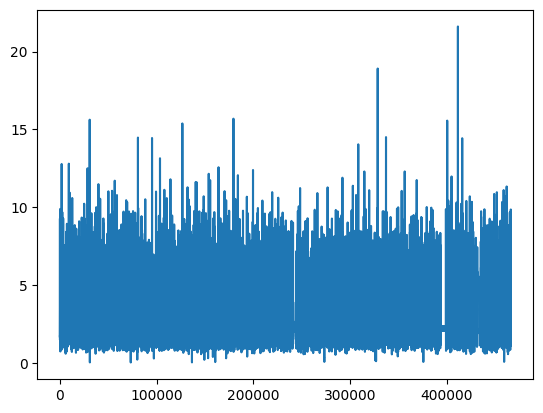

In [ ]:
df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"].plot()

<Axes: >

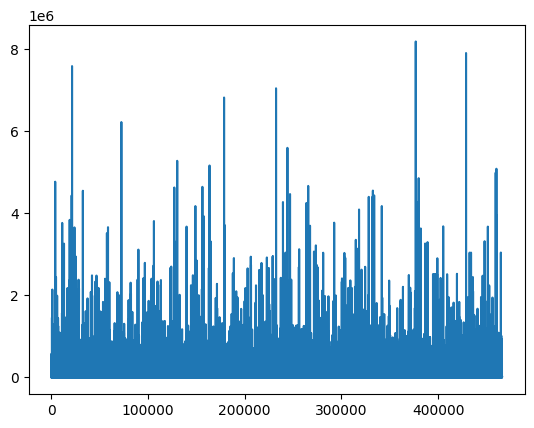

In [ ]:
df["Conso_5_usages_é_primaire_ademe"].plot()

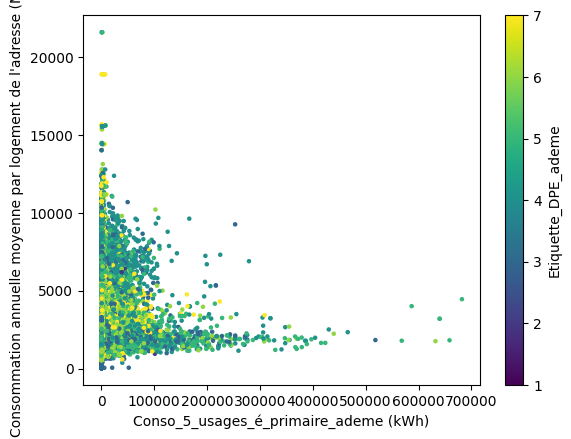

In [ ]:
import matplotlib.pyplot as plt

# Convert categorical data to numerical values
color_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
colors = df_clean["Etiquette_DPE_ademe"].map(color_mapping)

plt.scatter(
    (df_clean["Conso_5_usages_é_primaire_ademe"]/12 ).round(2),
    df_clean["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"]*1000,
    c=colors,
    cmap='viridis',
    s=5)

plt.xlabel("Conso_5_usages_é_primaire_ademe (kWh)")
plt.ylabel("Consommation annuelle moyenne par logement de l'adresse (MWh)")
plt.colorbar(label='Etiquette_DPE_ademe')
plt.show()

In [ ]:
(df_clean[["Conso_5_usages_é_primaire_ademe"]]/12).describe().round(3)
# Conso_5_usages_é_primaire_ademe : consommation annuelle  5 usages (ecs/chauffage/climatisation/eclairage/auxiliaires)en 
# energie finale(déduit de la production pv autoconsommée)  (kWhef/an)


,Conso_5_usages_é_primaire_ademe
count,437072.000
mean,1683.389
std,7836.890
min,34.875
25%,663.725
50%,976.592
75%,1391.708
max,681998.742


In [ ]:
(df_clean[ ["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"]]*1000).describe().round(3)

,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban
count,437073.000
mean,2942.075
std,1506.101
min,30.000
25%,1868.000
50%,2661.000
75%,3538.000
max,21607.000


In [2]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet', engine='pyarrow')
df.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,25827.1,0.0,2621.9,Paris,4670.2,0.0,2621.9,0,25827.1,1962.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
1,1318.3,100.0,1153.0,Paris,79.4,NaN,1153.0,0,1318.3,458.0,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
2,49222.4,100.0,1772.3,Paris,8796.8,3046.7,0.0,0,47488.7,3705.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
3,2468.6,100.0,1150.6,Paris,153.9,NaN,1150.6,0,2468.6,598.1,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None
4,2526.3,100.0,1132.2,Paris,157.8,NaN,1132.2,0,2526.3,602.4,...,6861175.94,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,0.71698,Rue de Rennes,2.328325,48.84874,None


In [ ]:
class Nettoyage:
    def __init__(self, df):
        # Copier le DataFrame pour ne pas modifier l'original
        self.df = df.copy()
        
    def delete_colnan(self, tauxseuil):
        # Afficher le nombre initial de colonnes
        print("Le dataframe contient initialement ", len(self.df.columns), " colonnes.")
        print("Start processing: identification des colonnes avec des valeurs manquantes...")
        
        # Liste des colonnes à supprimer
        nanames = []
        
        # Parcourir les colonnes et vérifier les taux de valeurs manquantes
        for c in self.df.columns:
            tauxnan = round(self.df[c].isna().sum() / len(self.df), 2)
            if tauxnan >= tauxseuil:
                nanames.append(c)
        
        # Afficher le nombre de colonnes à supprimer
        print(f"Il y a {len(nanames)} colonnes avec au moins {tauxseuil * 100}% de valeurs manquantes.")
        print("Start processing: suppression des colonnes...")
        
        # Supprimer les colonnes avec un taux de valeurs manquantes trop élevé
        df_clean = self.df.drop(nanames, axis=1)
        
        # Afficher le résultat
        print("Done")
        print(f"Il reste {len(df_clean.columns)} colonnes.")
        
        # Retourner le DataFrame nettoyé
        return df_clean


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464576 entries, 0 to 464575
Columns: 280 entries, Conso_chauffage_dépensier_é_finale_ademe to _type_enedis_with_ban
dtypes: float64(142), int64(12), object(126)
memory usage: 992.4+ MB


In [ ]:
# Recherche des valeurs manquantes
tauxseuil = 0.9
nanames = []

# Identifier les colonnes avec un taux de valeurs manquantes supérieur ou égal au seuil
for c in df.columns:
    tauxnan = round(df[c].isna().sum() / len(df), 2)
    if tauxnan >= tauxseuil:
        nanames.append(c)

# Afficher les résultats
print(f"Il y a {len(nanames)} colonnes avec au moins {tauxseuil * 100}% de valeurs manquantes.")
print("Colonnes à supprimer :", nanames)

# Créer un DataFrame nettoyé en supprimant les colonnes identifiées
df_clean = df.copy().drop(nanames, axis=1)

# Vérification du DataFrame nettoyé
print(f"Le DataFrame nettoyé contient maintenant {len(df_clean.columns)} colonnes.")
print(df_clean.head())


Il y a 76 colonnes avec au moins 90.0% de valeurs manquantes.
Colonnes à supprimer : ['_score_ademe', 'Conso_chauffage_dépensier_installation_chauffage_n°2_ademe', 'Configuration_installation_chauffage_n°2_ademe', 'Type_installation_chauffage_n°2_ademe', 'Surface_chauffée_installation_chauffage_n°2_ademe', 'Description_installation_chauffage_n°2_ademe', 'Type_émetteur_installation_chauffage_n°2_ademe', 'Description_générateur_chauffage_n°1_installation_n°2_ademe', 'Conso_chauffage_générateur_n°1_installation_n°2_ademe', 'Conso_chauffage_installation_chauffage_n°2_ademe', 'Usage_générateur_n°1_installation_n°2_ademe', 'Type_énergie_générateur_n°1_installation_n°2_ademe', 'Conso_chauffage_dépensier_générateur_n°1_installation_n°2_ademe', 'Type_générateur_n°1_installation_n°2_ademe', 'Date_installation_générateur_ECS_n°1_ademe', 'N°_DPE_remplacé_ademe', 'Qualité_isolation_plancher_haut_comble_aménagé_ademe', 'Nom_résidence_ademe', 'COP_générateur_ECS_n°1_ademe', 'Type_générateur_froid_ade

In [ ]:
round(df_clean.describe(),2)

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,Conso_é_finale_dépensier_installation_ECS_ademe,Surface_chauffée_installation_chauffage_n°1_ademe,Coordonnée_cartographique_X_(BAN)_ademe,Nombre_niveau_logement_ademe,Apports_internes_saison_froid_ademe,Déperditions_murs_ademe,Conso_5_usages_par_m²_é_primaire_ademe,Coût_refroidissement_ademe,Ubat_W/m²_K_ademe,Coût_ECS_dépensier_ademe,Emission_GES_auxiliaires_ademe,Emission_GES_5_usages_par_m²_ademe,Emission_GES_éclairage_ademe,Apports_solaires_saison_froid_ademe,Conso_ECS_dépensier_é_finale_ademe,N°_étage_appartement_ademe,Coût_ECS_ademe,Surface_habitable_desservie_par_installation_ECS_ademe,Coût_éclairage_ademe,Coût_total_5_usages_énergie_n°2_ademe,Coût_total_5_usages_énergie_n°1_ademe,Conso_refroidissement_é_finale_ademe,Conso_chauffage_é_primaire_ademe,Conso_éclairage_é_primaire_ademe,Emission_GES_5_usages_énergie_n°1_ademe,Emission_GES_5_usages_énergie_n°2_ademe,Emission_GES_ECS_énergie_n°2_ademe,Emission_GES_ECS_énergie_n°1_ademe,Nombre_appartement_ademe,Production_électricité_PV_(kWhep/an)_ademe,Conso_5_usages_é_finale_ademe,Nombre_logements_desservis_par_installation_ECS_ademe,Conso_refroidissement_é_primaire_ademe,Surface_habitable_logement_ademe,Deperditions_planchers_bas_ademe,Coordonnée_cartographique_Y_(BAN)_ademe,_rand_ademe,Emission_GES_ECS_dépensier_ademe,Emission_GES_chauffage_énergie_n°2_ademe,Emission_GES_chauffage_énergie_n°1_ademe,Conso_é_finale_dépensier_générateur_ECS_n°1_ademe,Emission_GES_refroidissement_ademe,Emission_GES_ECS_ademe,Coût_ECS_énergie_n°2_ademe,Coût_ECS_énergie_n°1_ademe,Conso_ECS_é_finale_ademe,Emission_GES_5_usages_ademe,Conso_éclairage_é_finale_ademe,Coût_refroidissement_dépensier_ademe,Deperditions_planchers_hauts_ademe,Emission_GES_refroidissement_dépensier_ademe,Apports_solaires_saison_chauffe_ademe,Conso_chauffage_générateur_n°1_installation_n°1_ademe,Coût_chauffage_ademe,Déperditions_renouvellement_air_ademe,Déperditions_portes_ademe,Conso_chauffage_installation_chauffage_n°1_ademe,Conso_ECS_dépensier_é_primaire_ademe,Conso_refroidissement_dépensier_é_finale_ademe,Version_DPE_ademe,Deperditions_baies_vitrées_ademe,Conso_chauffage_dépensier_générateur_n°1_installation_n°1_ademe,Déperditions_ponts_thermiques_ademe,Emission_GES_chauffage_dépensier_ademe,Besoin_chauffage_ademe,Conso_ECS_é_primaire_ademe,Conso_5_usages_é_finale_énergie_n°1_ademe,Conso_5_usages_é_finale_énergie_n°2_ademe,Conso_auxiliaires_é_primaire_ademe,Conso_auxiliaires_é_finale_ademe,Conso_é_finale_générateur_ECS_n°1_ademe,Conso_chauffage_é_finale_ademe,Coût_chauffage_dépensier_ademe,Conso_refroidissement_dépensier_é_primaire_ademe,Besoin_refroidissement_dépensier_ademe,Coût_chauffage_énergie_n°1_ademe,_i_ademe,Coût_chauffage_énergie_n°2_ademe,Apports_internes_saison_chauffe__ademe,Conso_5_usages/m²_é_finale_ademe,Hauteur_sous-plafond_ademe,Coût_auxiliaires_ademe,Conso_chauffage_dépensier_é_primaire_ademe,Score_BAN_ademe,Deperditions_enveloppe_ademe,Conso_5_usages_é_primaire_ademe,Conso_chauffage_é_finale_énergie_n°2_ademe,Conso_chauffage_é_finale_énergie_n°1_ademe,Surface_habitable_immeuble_ademe,Année_construction_ademe,Nombre_niveau_immeuble_ademe,Unnamed: 0_enedis_with_ban,Année_enedis_with_ban,Numéro de voie_enedis_with_ban,code_commune_enedis_with_ban,Nombre de logements_enedis_with_ban,Consommation annuelle totale de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne de la commune (MWh)_enedis_with_ban,Code EPCI_enedis_with_ban,Code Département_enedis_with_ban,Code Région_enedis_with_ban,Tri des adresses_enedis_with_ban,score_enedis_with_ban,postcode_enedis_with_ban,citycode_enedis_with_ban,x_enedis_with_ban,y_enedis_w

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464576 entries, 0 to 464575
Columns: 204 entries, Conso_chauffage_dépensier_é_finale_ademe to _type_enedis_with_ban
dtypes: Float64(101), Int64(18), boolean(6), string(79)
memory usage: 759.8 MB


In [ ]:
# Afficher les types des colonnes de manière lisible
column_types = df_clean.dtypes

# Afficher les types sous forme de tableau
print(column_types)

# Si tu veux aussi le mettre dans un format plus lisible, tu peux le convertir en DataFrame
column_types_df = column_types.reset_index()
column_types_df.columns = ['Column', 'Data Type']
print(column_types_df)

# Si tu veux l'enregistrer dans un fichier CSV pour un usage ultérieur :
column_types_df.to_csv('column_data_types.csv', index=False)


Conso_chauffage_dépensier_é_finale_ademe    float64
Volume_stockage_générateur_ECS_n°1_ademe    float64
Conso_é_finale_installation_ECS_ademe       float64
Nom__commune_(BAN)_ademe                     object
Emission_GES_chauffage_ademe                float64
                                             ...   
importance_enedis_with_ban                  float64
street_enedis_with_ban                       object
lon_enedis_with_ban                         float64
lat_enedis_with_ban                         float64
_type_enedis_with_ban                        object
Length: 204, dtype: object
                                       Column Data Type
0    Conso_chauffage_dépensier_é_finale_ademe   float64
1    Volume_stockage_générateur_ECS_n°1_ademe   float64
2       Conso_é_finale_installation_ECS_ademe   float64
3                    Nom__commune_(BAN)_ademe    object
4                Emission_GES_chauffage_ademe   float64
..                                        ...       ...
199      

In [ ]:
print(df_clean.head())

   Conso_chauffage_dépensier_é_finale_ademe  \
0                                   25827.1   
1                                    1318.3   
2                                   49222.4   
3                                    2468.6   
4                                    2526.3   

   Volume_stockage_générateur_ECS_n°1_ademe  \
0                                       0.0   
1                                     100.0   
2                                     100.0   
3                                     100.0   
4                                     100.0   

   Conso_é_finale_installation_ECS_ademe Nom__commune_(BAN)_ademe  \
0                                 2621.9                    Paris   
1                                 1153.0                    Paris   
2                                 1772.3                    Paris   
3                                 1150.6                    Paris   
4                                 1132.2                    Paris   

   Emission_GES_cha

In [ ]:
df_clean.to_csv('df_clean.csv', index=False)

Nombre de DPE par catégorie :
Etiquette_DPE_ademe
D    133890
E    130053
C     73601
F     66814
G     56236
B      3901
A        81
Name: count, dtype: int64


/var/folders/qr/bt940jmx4v98pkf6gyz5ynmm0000gn/T/ipykernel_33790/1343135022.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dpe_counts.index, y=dpe_counts.values, palette='viridis')


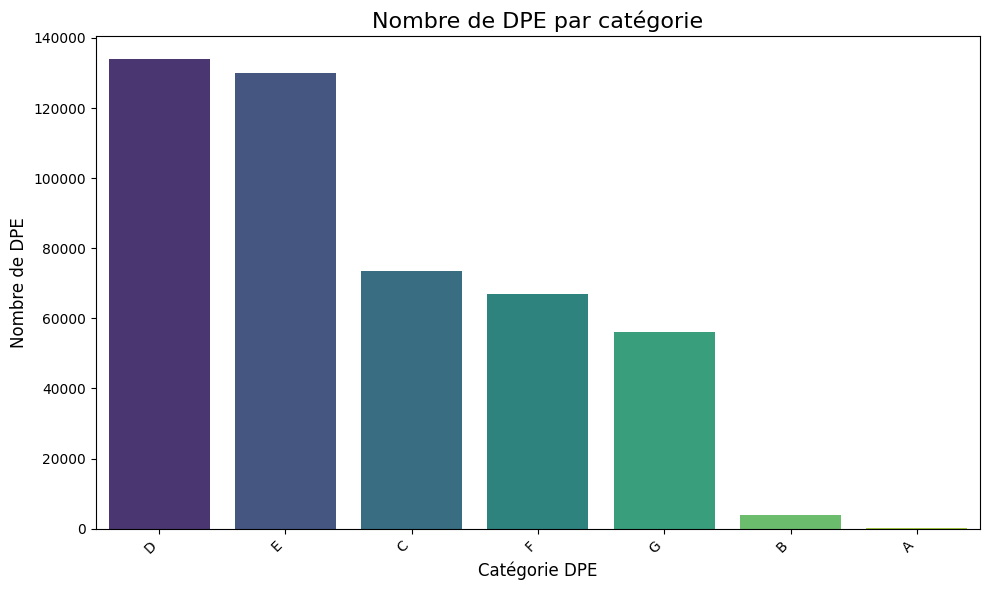

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compter le nombre de DPE par catégorie
dpe_counts = df_clean['Etiquette_DPE_ademe'].value_counts()

# 2. Afficher les comptages
print("Nombre de DPE par catégorie :")
print(dpe_counts)

# 3. Créer le plot
plt.figure(figsize=(10,6))
sns.barplot(x=dpe_counts.index, y=dpe_counts.values, palette='viridis')

# 4. Ajouter les labels et le titre
plt.title('Nombre de DPE par catégorie', fontsize=16)
plt.xlabel('Catégorie DPE', fontsize=12)
plt.ylabel('Nombre de DPE', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotation des étiquettes pour meilleure lisibilité

# 5. Afficher le graphique
plt.tight_layout()
plt.show()


In [ ]:
# Afficher le nombre de lignes et de colonnes
nombre_lignes, nombre_colonnes = df_clean.shape

print(f"Nombre de lignes : {nombre_lignes}")
print(f"Nombre de colonnes : {nombre_colonnes}")


Nombre de lignes : 464576
Nombre de colonnes : 204


In [ ]:
# Changer les types des colonnes en fonction de leur contenu
df_clean = df_clean.convert_dtypes()

# Afficher les types des colonnes après conversion pour vérifier
print(df_clean.dtypes)

Conso_chauffage_dépensier_é_finale_ademe           Float64
Volume_stockage_générateur_ECS_n°1_ademe           Float64
Conso_é_finale_installation_ECS_ademe              Float64
Nom__commune_(BAN)_ademe                    string[python]
Emission_GES_chauffage_ademe                       Float64
                                                 ...      
importance_enedis_with_ban                         Float64
street_enedis_with_ban                      string[python]
lon_enedis_with_ban                                Float64
lat_enedis_with_ban                                Float64
_type_enedis_with_ban                       string[python]
Length: 204, dtype: object


In [ ]:
# Pour convertir toutes les colonnes d'objets en datetime, numeric ou string
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':  # Si c'est un objet (typiquement texte)
        try:
            # Essayer de convertir en datetime
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        except Exception:
            # Si échec, essayer de convertir en numérique
            try:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            except Exception:
                # Sinon, rester en string
                df_clean[col] = df_clean[col].astype(str)

# Afficher les types des colonnes après la conversion
print(df_clean.dtypes)

Conso_chauffage_dépensier_é_finale_ademe           Float64
Volume_stockage_générateur_ECS_n°1_ademe           Float64
Conso_é_finale_installation_ECS_ademe              Float64
Nom__commune_(BAN)_ademe                    string[python]
Emission_GES_chauffage_ademe                       Float64
                                                 ...      
importance_enedis_with_ban                         Float64
street_enedis_with_ban                      string[python]
lon_enedis_with_ban                                Float64
lat_enedis_with_ban                                Float64
_type_enedis_with_ban                       string[python]
Length: 204, dtype: object


In [ ]:
df_clean.to_csv('df-clean.csv', index=False)


In [ ]:
print(df_clean.head())

   Conso_chauffage_dépensier_é_finale_ademe  \
0                                   25827.1   
1                                    1318.3   
2                                   49222.4   
3                                    2468.6   
4                                    2526.3   

   Volume_stockage_générateur_ECS_n°1_ademe  \
0                                       0.0   
1                                     100.0   
2                                     100.0   
3                                     100.0   
4                                     100.0   

   Conso_é_finale_installation_ECS_ademe Nom__commune_(BAN)_ademe  \
0                                 2621.9                    Paris   
1                                 1153.0                    Paris   
2                                 1772.3                    Paris   
3                                 1150.6                    Paris   
4                                 1132.2                    Paris   

   Emission_GES_cha

In [ ]:
df_clean.info

<bound method DataFrame.info of         Conso_chauffage_dépensier_é_finale_ademe  \
0                                        25827.1   
1                                         1318.3   
2                                        49222.4   
3                                         2468.6   
4                                         2526.3   
...                                          ...   
464571                                   10005.5   
464572                                   24006.5   
464573                                    9978.5   
464574                                    8399.9   
464575                                    8820.1   

        Volume_stockage_générateur_ECS_n°1_ademe  \
0                                            0.0   
1                                          100.0   
2                                          100.0   
3                                          100.0   
4                                          100.0   
...                            

In [ ]:
# Identifier les colonnes avec des valeurs manquantes
missing_columns = df_clean.columns[df_clean.isnull().any()]

# Afficher ces colonnes
print("Colonnes avec des valeurs manquantes :")
print(missing_columns)


Colonnes avec des valeurs manquantes :
Index(['Volume_stockage_générateur_ECS_n°1_ademe',
       'Conso_é_finale_installation_ECS_ademe', 'Nom__commune_(BAN)_ademe',
       'Conso_ECS_é_finale_énergie_n°2_ademe', 'Besoin_refroidissement_ademe',
       'Conso_chauffage_dépensier_installation_chauffage_n°1_ademe',
       'Coût_total_5_usages_ademe',
       'Configuration_installation_chauffage_n°1_ademe',
       'Conso_é_finale_dépensier_installation_ECS_ademe',
       'Configuration_installation_ECS_ademe',
       ...
       'Conso_chauffage_é_finale_énergie_n°2_ademe',
       'Surface_habitable_immeuble_ademe', 'Année_construction_ademe',
       'Qualité_isolation_plancher_haut_toit_terrase_ademe',
       'Catégorie_ENR_ademe', 'Nombre_niveau_immeuble_ademe',
       'Appartement_non_visité_(0/1)_ademe', 'N°_DPE_immeuble_associé_ademe',
       'housenumber_enedis_with_ban', '_type_enedis_with_ban'],
      dtype='object', length=107)


In [ ]:
# Si tu veux l'enregistrer dans un fichier CSV pour un usage ultérieur :
df_clean.to_csv('df-clean.csv', index=False)


In [ ]:
print(df_clean.head())

   Conso_chauffage_dépensier_é_finale_ademe  \
0                                   25827.1   
1                                    1318.3   
2                                   49222.4   
3                                    2468.6   
4                                    2526.3   

   Volume_stockage_générateur_ECS_n°1_ademe  \
0                                       0.0   
1                                     100.0   
2                                     100.0   
3                                     100.0   
4                                     100.0   

   Conso_é_finale_installation_ECS_ademe Nom__commune_(BAN)_ademe  \
0                                 2621.9                    Paris   
1                                 1153.0                    Paris   
2                                 1772.3                    Paris   
3                                 1150.6                    Paris   
4                                 1132.2                    Paris   

   Emission_GES_cha

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 444192 entries, 0 to 464575
Columns: 204 entries, Conso_chauffage_dépensier_é_finale_ademe to _type_enedis_with_ban
dtypes: Float64(101), Int64(18), boolean(6), string(79)
memory usage: 729.9 MB


In [ ]:
# Nombre de lignes avec des valeurs manquantes
missing_rows_count = df_clean.isnull().any(axis=1).sum()
print(f"Nombre de lignes avec des valeurs manquantes : {missing_rows_count}")

# Nombre de lignes dupliquées
duplicate_rows_count = df_clean.duplicated().sum()
print(f"Nombre de lignes dupliquées : {duplicate_rows_count}")


Nombre de lignes avec des valeurs manquantes : 444192
Nombre de lignes dupliquées : 0


In [ ]:
# Supprimer les lignes dupliquées
df_clean = df_clean.drop_duplicates()

# Afficher le nombre de lignes restantes après suppression
print(f"Nombre de lignes après suppression des doublons : {len(df_clean)}")

Nombre de lignes après suppression des doublons : 444192


In [ ]:
# Filtrer les lignes où toutes les valeurs sont NaN
na_rows = df_clean[df_clean.isnull().all(axis=1)]

# Afficher ces lignes
print(na_rows)


Empty DataFrame
Columns: [Conso_chauffage_dépensier_é_finale_ademe, Volume_stockage_générateur_ECS_n°1_ademe, Conso_é_finale_installation_ECS_ademe, Nom__commune_(BAN)_ademe, Emission_GES_chauffage_ademe, Conso_ECS_é_finale_énergie_n°2_ademe, Conso_ECS_é_finale_énergie_n°1_ademe, Besoin_refroidissement_ademe, Conso_chauffage_dépensier_installation_chauffage_n°1_ademe, Coût_total_5_usages_ademe, Configuration_installation_chauffage_n°1_ademe, Conso_é_finale_dépensier_installation_ECS_ademe, Configuration_installation_ECS_ademe, Type_installation_chauffage_n°1_ademe, Surface_chauffée_installation_chauffage_n°1_ademe, Coordonnée_cartographique_X_(BAN)_ademe, Nombre_niveau_logement_ademe, Apports_internes_saison_froid_ademe, Type_installation_ECS_(général)_ademe, Déperditions_murs_ademe, Conso_5_usages_par_m²_é_primaire_ademe, Coût_refroidissement_ademe, Ubat_W/m²_K_ademe, Usage_générateur_ECS_n°1_ademe, Coût_ECS_dépensier_ademe, Emission_GES_auxiliaires_ademe, Emission_GES_5_usages_par_m²

In [ ]:
# Vérifier toutes les colonnes où toutes les valeurs sont identiques
for col in df_clean.columns:
    if df_clean[col].nunique() == 1:  # Si une seule valeur unique est présente
        print(f"Toutes les lignes de la colonne '{col}' contiennent la même valeur :")
        print(df_clean[[col]])


Toutes les lignes de la colonne 'Modèle_DPE_ademe' contiennent la même valeur :
                     Modèle_DPE_ademe
0       DPE 3CL 2021 méthode logement
1       DPE 3CL 2021 méthode logement
2       DPE 3CL 2021 méthode logement
3       DPE 3CL 2021 méthode logement
4       DPE 3CL 2021 méthode logement
...                               ...
464571  DPE 3CL 2021 méthode logement
464572  DPE 3CL 2021 méthode logement
464573  DPE 3CL 2021 méthode logement
464574  DPE 3CL 2021 méthode logement
464575  DPE 3CL 2021 méthode logement

[444192 rows x 1 columns]
Toutes les lignes de la colonne 'N°_département_(BAN)_ademe' contiennent la même valeur :
       N°_département_(BAN)_ademe
0                              75
1                              75
2                              75
3                              75
4                              75
...                           ...
464571                         75
464572                         75
464573                         75
464574 

In [ ]:
# Liste des colonnes à vérifier
columns_to_check = [
    'nom_commune_enedis_with_ban',
        'city_enedis_with_ban', 
    'code_commune_enedis_with_ban', 
    'Code Département_enedis_with_ban',
    'context_enedis_with_ban',
    '_type_enedis_with_ban'
]

# Vérifier chaque colonne et afficher si toutes les valeurs sont identiques
for col in columns_to_check:
    if df_clean[col].nunique() == 1:  # Si la colonne a une seule valeur unique
        print(f"Toutes les lignes de la colonne '{col}' contiennent la même valeur :")
        print(df_clean[[col]])  # Afficher cette colonne
    else:
        print(f"La colonne '{col}' ne contient pas la même valeur dans toutes les lignes.")


Toutes les lignes de la colonne 'nom_commune_enedis_with_ban' contiennent la même valeur :
       nom_commune_enedis_with_ban
0                            Paris
1                            Paris
2                            Paris
3                            Paris
4                            Paris
...                            ...
464571                       Paris
464572                       Paris
464573                       Paris
464574                       Paris
464575                       Paris

[444192 rows x 1 columns]
Toutes les lignes de la colonne 'city_enedis_with_ban' contiennent la même valeur :
       city_enedis_with_ban
0                     Paris
1                     Paris
2                     Paris
3                     Paris
4                     Paris
...                     ...
464571                Paris
464572                Paris
464573                Paris
464574                Paris
464575                Paris

[444192 rows x 1 columns]
Toutes les lign

In [ ]:
# Liste des colonnes à supprimer
columns_to_drop = [
    'nom_commune_enedis_with_ban',
    'city_enedis_with_ban', 
    'code_commune_enedis_with_ban', 
    'Code Département_enedis_with_ban',
    'context_enedis_with_ban',
    '_type_enedis_with_ban'
]

# Supprimer les colonnes du DataFrame
df_clean = df_clean.drop(columns=columns_to_drop)

# Afficher le DataFrame après la suppression des colonnes
print(df_clean)


        Conso_chauffage_dépensier_é_finale_ademe  \
0                                        25827.1   
1                                         1318.3   
2                                        49222.4   
3                                         2468.6   
4                                         2526.3   
...                                          ...   
464571                                   10005.5   
464572                                   24006.5   
464573                                    9978.5   
464574                                    8399.9   
464575                                    8820.1   

        Volume_stockage_générateur_ECS_n°1_ademe  \
0                                            0.0   
1                                          100.0   
2                                          100.0   
3                                          100.0   
4                                          100.0   
...                                          ...   
464571     

In [ ]:
    # Liste des colonnes à afficher
columns_to_display = [
    'Code_postal_(brut)_ademe',
    'Code_postal_(BAN)_ademe',
    'Adresse_(BAN)_ademe',
    'Complément_d\'adresse_bâtiment_ademe',
    'Nom__rue_(BAN)_ademe',
    'Code_INSEE_(BAN)_ademe',
    'Nom IRIS_enedis_with_ban',
    'Numéro de voie_enedis_with_ban',
    'Type de voie_enedis_with_ban',
    'Libellé de voie_enedis_with_ban',
    'adresse_enedis_with_ban',
    'full_adress_enedis_with_ban',
    'label_enedis_with_ban',
    'name_enedis_with_ban',
    'postcode_enedis_with_ban',
    'citycode_enedis_with_ban',
    'type_enedis_with_ban',
    'street_enedis_with_ban'
]

# Sélectionner ces colonnes et afficher le head
df_clean[columns_to_display].head()


,Code_postal_(brut)_ademe,Code_postal_(BAN)_ademe,Adresse_(BAN)_ademe,Complément_d'adresse_bâtiment_ademe,Nom__rue_(BAN)_ademe,Code_INSEE_(BAN)_ademe,Nom IRIS_enedis_with_ban,Numéro de voie_enedis_with_ban,Type de voie_enedis_with_ban,Libellé de voie_enedis_with_ban,adresse_enedis_with_ban,full_adress_enedis_with_ban,label_enedis_with_ban,name_enedis_with_ban,postcode_enedis_with_ban,citycode_enedis_with_ban,type_enedis_with_ban,street_enedis_with_ban
0,75006,75006,108 Rue de Rennes 75006 Paris,00010260/JSS,Rue de Rennes,75106,Notre-Dame des Champs 10,108,RUE,DE RENNES,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108 Rue de Rennes,75006,75106,housenumber,Rue de Rennes
1,75006,75006,108 Rue de Rennes 75006 Paris,22IMT10507_p04,Rue de Rennes,75106,Notre-Dame des Champs 10,108,RUE,DE RENNES,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108 Rue de Rennes,75006,75106,housenumber,Rue de Rennes
2,75006,75006,108 Rue de Rennes 75006 Paris,108 rue de Rennes 75006 Paris 3,Rue de Rennes,75106,Notre-Dame des Champs 10,108,RUE,DE RENNES,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108 Rue de Rennes,75006,75106,housenumber,Rue de Rennes
3,75006,75006,108 Rue de Rennes 75006 Paris,22IMT10507_p01,Rue de Rennes,75106,Notre-Dame des Champs 10,108,RUE,DE RENNES,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108 Rue de Rennes,75006,75106,housenumber,Rue de Rennes
4,75006,75006,108 Rue de Rennes 75006 Paris,22IMT10507,Rue de Rennes,75106,Notre-Dame des Champs 10,108,RUE,DE RENNES,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108 Rue de Rennes,75006,75106,housenumber,Rue de Rennes


In [ ]:
# Liste des colonnes à supprimer
columns_to_dropp = [
    'Code_postal_(brut)_ademe',
    'Code_postal_(BAN)_ademe',
    'Adresse_(BAN)_ademe',
    'Complément_d\'adresse_bâtiment_ademe',
    'Nom__rue_(BAN)_ademe',
    'Code_INSEE_(BAN)_ademe',
    'Nom IRIS_enedis_with_ban',
    'Numéro de voie_enedis_with_ban',
    'Type de voie_enedis_with_ban',
    'Libellé de voie_enedis_with_ban',
    'adresse_enedis_with_ban',
    'full_adress_enedis_with_ban',
    'label_enedis_with_ban',
    'name_enedis_with_ban',
    'postcode_enedis_with_ban',
    'citycode_enedis_with_ban',
    'type_enedis_with_ban',
    'street_enedis_with_ban'
    'housenumber_enedis_with_ban'
]

# Supprimer les colonnes du DataFrame
df_clean = df_clean.drop(columns=columns_to_dropp)

# Afficher le DataFrame après la suppression des colonnes
print(df_clean)


KeyError: '[\'Code_postal_(brut)_ademe\', \'Code_postal_(BAN)_ademe\', \'Adresse_(BAN)_ademe\', "Complément_d\'adresse_bâtiment_ademe", \'Nom__rue_(BAN)_ademe\', \'Code_INSEE_(BAN)_ademe\', \'Nom IRIS_enedis_with_ban\', \'Numéro de voie_enedis_with_ban\', \'Type de voie_enedis_with_ban\', \'Libellé de voie_enedis_with_ban\', \'adresse_enedis_with_ban\', \'full_adress_enedis_with_ban\', \'label_enedis_with_ban\', \'name_enedis_with_ban\', \'postcode_enedis_with_ban\', \'citycode_enedis_with_ban\', \'type_enedis_with_ban\', \'street_enedis_with_banhousenumber_enedis_with_ban\'] not found in axis'

In [ ]:
print(df_clean)

        Conso_chauffage_dépensier_é_finale_ademe  \
0                                        25827.1   
1                                         1318.3   
2                                        49222.4   
3                                         2468.6   
4                                         2526.3   
...                                          ...   
464571                                   10005.5   
464572                                   24006.5   
464573                                    9978.5   
464574                                    8399.9   
464575                                    8820.1   

        Volume_stockage_générateur_ECS_n°1_ademe  \
0                                            0.0   
1                                          100.0   
2                                          100.0   
3                                          100.0   
4                                          100.0   
...                                          ...   
464571     

In [ ]:
 # Liste des nouvelles colonnes à afficher
columns_to_display_2 = [
    'Nom__commune_(BAN)_ademe',
    'Besoin_refroidissement_ademe',
    'Configuration_installation_chauffage_n°1_ademe',
    'Complément_d\'adresse_logement_ademe',
    'Adresse_brute_ademe',
    'Statut_géocodage_ademe',
    'Nombre_appartement_ademe',
    'N°_département_(BAN)_ademe',
    'N°_région_(BAN)_ademe',
    'Méthode_application_DPE_ademe',
    'Type_bâtiment_ademe',
    'Type_énergie_principale_chauffage_ademe',
    'Type_énergie_générateur_n°1_installation_n°1_ademe',
    '_geopoint_ademe',
    'lon_enedis_with_ban',
    'lat_enedis_with_ban'
]

# Sélectionner ces colonnes et afficher le head
df_clean[columns_to_display_2]


,Nom__commune_(BAN)_ademe,Besoin_refroidissement_ademe,Configuration_installation_chauffage_n°1_ademe,Complément_d'adresse_logement_ademe,Adresse_brute_ademe,Statut_géocodage_ademe,Nombre_appartement_ademe,N°_département_(BAN)_ademe,N°_région_(BAN)_ademe,Méthode_application_DPE_ademe,Type_bâtiment_ademe,Type_énergie_principale_chauffage_ademe,Type_énergie_générateur_n°1_installation_n°1_ademe,_geopoint_ademe,lon_enedis_with_ban,lat_enedis_with_ban
0,Paris,0,Installation de chauffage simple,Etage 5,108 rue de Rennes,adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Gaz naturel,Gaz naturel,"48.84874002181082,2.3283249797728387",2.328325,48.84874
1,Paris,0,Installation de chauffage simple,7ème étage,108 rue de Rennes (studio 5),adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Électricité,Électricité,"48.84874002181082,2.3283249797728387",2.328325,48.84874
2,Paris,0,Installation de chauffage simple,3ème sur cour,108 rue de Rennes,adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Gaz naturel,Gaz naturel,"48.84874002181082,2.3283249797728387",2.328325,48.84874
3,Paris,0,Installation de chauffage simple,7ème étage,108 rue de Rennes (studio 2),adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Électricité,Électricité,"48.84874002181082,2.3283249797728387",2.328325,48.84874
4,Paris,0,Installation de chauffage simple,7ème étage,108 rue de Rennes (studio 1),adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Électricité,Électricité,"48.84874002181082,2.3283249797728387",2.328325,48.84874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464571,Paris,0,Installation de chauffage simple,Etage 6,56 boulevard Voltaire,adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Gaz naturel,Gaz naturel,"48.86284598949064,2.371325010492352",2.371325,48.862846
464572,Paris,0,Installation de chauffage simple,Etage 5; Porte Gauche,56 BOULEVARD VOLTAIRE,adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Gaz naturel,Gaz naturel,"48.86284598949064,2.371325010492352",2.371325,48.862846
464573,Paris,0,Installation de chauffage simple,Etage 6,56 boulevard Voltaire,adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Gaz naturel,Gaz naturel,"48.86284598949064,2.371325010492352",2.371325,48.862846
464574,Paris,0,Installation de chauffage simple,Bât.Rue - 6ème étage Droite,56 Boulevard Voltaire,adresse géocodée ban à l'adresse,1,75,11,dpe appartement individuel,appartement,Électricité,Électricité,"48.86284598949064,2.371325010492352",2.371325,48.862846


In [ ]:
df_clean.to_csv('df-clean.csv', index=False)